# Lecture 9 — Warm-up
## Reading a model: California housing, from coefficients to SHAP

**AI-powered Investment and Risk Management · UTS Business School**

---

Every explanation method in this lecture answers a question about a model. This notebook
teaches you to read those answers carefully, on data simple enough that you can check them
against your own intuition: house prices across California.

By the end you will be able to:

1. Describe a dataset's units, codings and quirks before modelling it — and explain why each
   one changes what a model can learn.
2. Interpret a regression coefficient correctly: in the right units, with the
   *holding-everything-else-constant* clause, and with a sense of how stable it is.
3. Show that a SHAP value for a linear model is exactly *coefficient × (value − average)*,
   and explain what SHAP adds when the model is not linear.
4. Read the standard plots — permutation importance, partial dependence and ICE, waterfall,
   force, beeswarm and decision plots — in both their native form and our Plotly versions.
5. Recognise when an explanation is extrapolating, and why a counterfactual needs both
   *actionability* and *plausibility* constraints.

### The through-line: four maps of California

Location turns out to matter more than anything else in this dataset, so we answer one
question — *what does the model think location is worth?* — four ways, each drawn on the
same axes:

| Map | What it shows | Part |
|---|---|---|
| **A** | The data: every block group at its coordinates, coloured by value | 2 |
| **B** | What a linear model *can* say about location: a tilted plane | 3 |
| **C** | Partial dependence: the average effect of location — including in the ocean | 7 |
| **D** | SHAP: what the black box attributes to location, block group by block group | 9 |

### How to use this notebook

It is long, deliberately. The **core path** takes about 35 minutes: read everything,
run everything, and skip the sections marked **★ Deep dive**, which you can return to
later. Collapsible *mathematics* blocks are optional throughout.

Runtime is about a minute on a laptop; the first run takes a little longer while the data
download.

### Why *this* dataset, in *this* lecture

The California housing dataset exists because another dataset was withdrawn.

For thirty years the standard teaching dataset for regression was **Boston housing**. In
scikit-learn 1.2 it was removed outright. The library's own documentation gives the reason:
one of its variables had been engineered on the assumption that racial self-segregation
raised house prices. The maintainers now discourage its use, with a single stated exception
— *unless the purpose of the code is to study and educate about ethical issues in data
science and machine learning.*

The replacement they point to is the dataset we are about to load. So the data in front of
you are a direct artefact of an ethical judgement, made by maintainers, years after the data
were collected. Keep that in view: **the ethical problem was in the features, and no amount
of model explanation would have surfaced it.** Someone had to read the codebook.

We will find something related, but subtler, in California by Part 9.

---
## Step 0 — Setup

Three groups of tools:

* **Data and models** — `pandas`, `numpy`, `statsmodels` (for regression tables with
  standard errors) and `scikit-learn`, whose gradient-boosting model is our black box.
* **Explanation** — `shap` for Shapley values, and `dice_ml` for counterfactuals in Part 10.
* **Plots** — `plotly` for everything we draw ourselves. `matplotlib` appears *only* because
  the native SHAP and scikit-learn explanation plots are built on it: this notebook shows
  each of those in its canonical form, so you will recognise them in papers and
  documentation, alongside a Plotly version where that adds something.

`airm9.py` is this lecture's helper module. It holds the data loaders, the map-drawing code
and the Plotly versions of the SHAP plots, so the notebook can concentrate on reading
results rather than on plotting mechanics.

Set `USE_LIVE = False` after your first successful run to work entirely offline.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import statsmodels.api as sm
import shap

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

import airm9 as A

pio.renderers.default = "notebook"   # use "colab" on Colab, "vscode" in VS Code
USE_LIVE = True                      # set False after the first run to work offline
SEED = 20260905

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(f"shap {shap.__version__} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

shap 0.52.0 | scikit-learn 1.9.0 | pandas 3.0.5


---
# Part 1 — Know your data

While not directly a finance example, the California housing dataset gives an intuitive
setting in which every explanation can be checked against common sense. That is exactly
what we need before trusting the same tools on a lending decision in `Lec09a`.

### California housing: detailed description

**Source.** The 1990 US Census, assembled into this form by R. Kelley Pace and Ronald Barry
(1997), *Sparse spatial autoregressions*, **Statistics & Probability Letters** 33(3),
291–297. scikit-learn distributes it as `fetch_california_housing()`.

**Unit of observation.** Each row is a **census block group** — the smallest geographical
unit for which the US Census Bureau publishes sample data, typically home to 600–3,000
people. Where this notebook says *district*, it means a block group. There are **20,640**
of them.

**Features** (all numeric; there are no categorical variables in scikit-learn's version):

| Feature | Meaning | Units |
|---|---|---|
| `MedInc` | median household income in the block group | **tens of thousands of dollars** — 3.9 means about \$39,000 |
| `HouseAge` | median age of the houses | years |
| `AveRooms` | average number of rooms per household | rooms |
| `AveBedrms` | average number of bedrooms per household | bedrooms |
| `Population` | number of people living in the block group | people |
| `AveOccup` | average number of household members | people per household |
| `Latitude` | latitude of the block group's centroid | degrees north |
| `Longitude` | longitude of the centroid | degrees east — **negative means west of Greenwich** |

**Target.** `MedHouseVal`, the median house value in the block group, in units of
**\$100,000**: a value of 2.5 means \$250,000. Keep this unit in mind — it is the single
most common source of error when interpreting models of this dataset.

**Characteristics.**
* Income and house values are right-skewed.
* Everything is an *aggregate* — a median or an average over a block group, never an
  individual house.
* Three variables are **top-coded** — capped at a maximum, so that every value above the cap
  is recorded as the cap — and one is also bottom-coded. Section 1.1 finds them.

**Applications.** Predictive modelling of house prices; exploratory analysis of how
demographic, geographic and economic factors relate; testing feature engineering and, as
here, explanation methods.

**Limitations.**
* The data are from 1990, in nominal dollars with no inflation adjustment; relationships
  need not carry over to today's housing market.
* The cap on house values means the model cannot distinguish a \$500,000 block group from
  a \$2 million one.
* The per-household ratios can take extreme values where a block group contains very few
  households — scikit-learn's own documentation mentions holiday resorts with many empty
  homes. Section 1.2 looks at them.
* Because every row is an aggregate, a relationship *across block groups* need not hold
  *for the households within them*. This is the ecological inference problem, and it limits
  what any explanation of this model can say about individual people.

### Loading the data

`A.load_california()` tries each source in turn and keeps the first that works: a copy in
your local `data/` folder (present if you cloned the subject repository, or saved by an
earlier run), then the subject repository online, then scikit-learn, then the `shap`
package, and finally a public mirror. Whatever it finds, it saves to `data/` so that the
next run needs no internet at all.

The reason for the chain is simple: a lab that depends on one third-party download stops
working the day that download moves. It prints which source it used.

In [2]:
X, y = A.load_california(use_live=USE_LIVE)
df = X.assign(MedHouseVal=y)
df.head(10)

California housing: 20,640 block groups, 8 features  [source: local copy (data/)]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,"2,401.0000",2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220
5,4.0368,52.0000,4.7617,1.1036,413.0000,2.1399,37.8500,-122.2500,2.6970
6,3.6591,52.0000,4.9319,0.9514,"1,094.0000",2.1284,37.8400,-122.2500,2.9920
7,3.1200,52.0000,4.7975,1.0618,"1,157.0000",1.7883,37.8400,-122.2500,2.4140
8,2.0804,42.0000,4.2941,1.1176,"1,206.0000",2.0269,37.8400,-122.2600,2.2670
9,3.6912,52.0000,4.9706,0.9902,"1,551.0000",2.1723,37.8400,-122.2500,2.6110


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
HouseAge,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,"20,640.0000",5.4290,2.4742,0.8462,4.4407,5.2291,6.0524,141.9091
AveBedrms,"20,640.0000",1.0967,0.4739,0.3333,1.0061,1.0488,1.0995,34.0667
Population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
AveOccup,"20,640.0000",3.0707,10.3860,0.6923,2.4297,2.8181,3.2823,"1,243.3333"
Latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
Longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
MedHouseVal,"20,640.0000",2.0686,1.1540,0.1500,1.1960,1.7970,2.6472,5.0000


### Hold out a test set — now

Before we look at any relationship, we set aside 20% of the block groups and do not touch
them until we evaluate a model. Every explanation in this notebook is an explanation of a
model we have already checked on data it never saw.

This matters more than it sounds. An explanation of an overfitted model faithfully
describes the noise it memorised; the plots look just as convincing either way.

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=SEED)
print(f"training: {len(Xtr):,} block groups | test: {len(Xte):,} block groups")

training: 16,512 block groups | test: 4,128 block groups


## 1.1 What the distributions tell you

Look at each histogram for three things: **skew** (a long tail on one side), **spikes**
(many identical values — often a sign of coding rather than nature), and **range** (values
that are implausible for what the variable claims to measure). The red dashed lines mark
values we will investigate. For the four count-and-ratio variables the plot trims the
extreme top 0.5% so that the bulk of the distribution is visible; we return to those
extremes in section 1.2.

In [5]:
A.plot_histogram_grid(
    df,
    caps={"MedHouseVal": 5.0, "HouseAge": 52, "MedInc": [0.4999, 15.0001]},
    title="Every variable, with the coded limits marked in red")

In [6]:
limits = []
for col, side in [("MedHouseVal", "max"), ("HouseAge", "max"),
                  ("MedInc", "max"), ("MedInc", "min")]:
    v = df[col]
    edge = v.max() if side == "max" else v.min()
    limits.append({"variable": col, "coded limit": side, "value": edge,
                   "block groups at the limit": int((v == edge).sum()),
                   "share (%)": 100 * (v == edge).mean()})
pd.DataFrame(limits).set_index("variable")

,coded limit,value,block groups at the limit,share (%)
variable,,,,
MedHouseVal,max,5.0000,965,4.6754
HouseAge,max,52.0000,1273,6.1676
MedInc,max,15.0001,49,0.2374
MedInc,min,0.4999,12,0.0581


Three spikes, and each one is a decision made when the data were published:

* **`MedHouseVal` is top-coded at 5.0 (\$500,000)** — roughly one block group in twenty.
  Their true median values are *at least* \$500,000; the data do not say by how much.
* **`HouseAge` is top-coded at 52 years** — about one block group in sixteen, the largest
  of the three. "52" here means "52 or older".
* **`MedInc` is top-coded at 15 and bottom-coded at about 0.5** — few block groups, but it
  means the highest- and lowest-income areas are flattened.

**Why this matters for explanation.** A model trained on censored data cannot learn what
happens beyond the cap, and it will be *confidently* wrong there: it has never seen a
\$900,000 block group, so it predicts one as \$500,000 and its explanation accounts for
\$500,000. The explanation is faithful to the model, and the model is faithful to a coding
decision. Neither is faithful to the housing market.

## 1.2 The extreme ratios

Three of the features are *ratios per household*. When a block group contains very few
households, those ratios can become enormous. scikit-learn's documentation points to
holiday resorts, where many homes stand empty. Occupancy extremes are plausibly the
opposite case — group quarters such as dormitories, barracks or prisons, where many people
are counted against very few households.

In [7]:
ratios = ["AveRooms", "AveBedrms", "AveOccup"]
summary = df[ratios].describe(percentiles=[0.5, 0.99]).T[["50%", "99%", "max"]]
summary.columns = ["median", "99th percentile", "maximum"]
display(summary)

extreme = df.nlargest(5, "AveOccup")[["AveOccup", "Population", "AveRooms",
                                      "Latitude", "Longitude", "MedHouseVal"]].copy()
extreme["nearest city"] = [f"{c} ({km:.0f} km)" for c, km in
                           (A.nearest_city(la, lo) for la, lo in
                            zip(extreme.Latitude, extreme.Longitude))]
extreme

,median,99th percentile,maximum
AveRooms,5.2291,10.3570,141.9091
AveBedrms,1.0488,2.1275,34.0667
AveOccup,2.8181,5.3948,"1,243.3333"


,AveOccup,Population,AveRooms,Latitude,Longitude,MedHouseVal,nearest city
19006,"1,243.3333","7,460.0000",3.1667,38.3200,-121.9800,1.3750,Sacramento (52 km)
3364,599.7143,"4,198.0000",5.1429,40.4100,-120.5100,0.6750,Redding (160 km)
16669,502.4615,"6,532.0000",9.0769,35.3200,-120.7000,3.5000,Santa Barbara (135 km)
13034,230.1724,"6,675.0000",8.2759,38.6900,-121.1500,2.2500,Sacramento (32 km)
9172,83.1714,"8,733.0000",5.1238,34.4700,-118.5900,1.5460,Los Angeles (57 km)


Compare the median with the maximum in each row. A block group averaging hundreds of
occupants per household is not describing households in any ordinary sense.

These rows are a tiny share of the data, but hold on to them. In Part 3 we will find that
**a few of them largely determine what a linear model says about occupancy** — and that
the published interpretation of that coefficient depends on whether they happened to be in
the sample.

## 1.3 The target against one feature

Change `X_FEATURE` to any column name and re-run the cell. Training block groups are blue
and test block groups orange: if the two clouds overlap, the split has not left any region
of the data unrepresented.

In [8]:
X_FEATURE = "MedInc"      # try "HouseAge", "AveOccup", "Latitude", ...

fig = go.Figure()
for name, Xs, ys, col in [("training", Xtr, ytr, A.BLUE), ("test", Xte, yte, A.ORANGE)]:
    fig.add_trace(go.Scattergl(x=Xs[X_FEATURE], y=ys * 100_000, mode="markers", name=name,
                               marker=dict(size=4, color=col, opacity=0.25)))
fig.add_hline(y=500_000, line=dict(color=A.RED, dash="dash"),
              annotation_text="the $500,000 cap", annotation_position="top left")
A.layout(fig, f"Median house value against {X_FEATURE}", height=520,
         xaxis_title=A.CA_LABELS.get(X_FEATURE, X_FEATURE),
         yaxis_title="median house value ($)")

## 1.4 How the features move together

Correlations will not tell you what causes what, but they tell you which coefficients in
Part 3 will be hard to separate — and one of them tells you something about the shape of
California.

In [9]:
A.plot_correlation_heatmap(df, title="Pearson correlations")

Three cells to find:

* **`MedInc` and `MedHouseVal` (about 0.69)** — the strongest single relationship with the
  target. No surprise.
* **`AveRooms` and `AveBedrms` (about 0.85)** — almost every extra room is partly an extra
  bedroom. When we ask a regression for the effect of one *holding the other fixed*, we are
  asking about a combination the data barely contain. Part 3 shows the consequence.
* **`Latitude` and `Longitude` (about −0.92)** — the most interesting. There is nothing
  economic about it: **California is a diagonal state.** As you travel north through it,
  you also travel west. The two coordinates are nearly redundant as recorded, which is why
  Part 3 will read them *together*.

---
# Part 2 — Where the districts are

Two reference maps first. They show the same state, and their grids look different for a
reason worth thirty seconds.

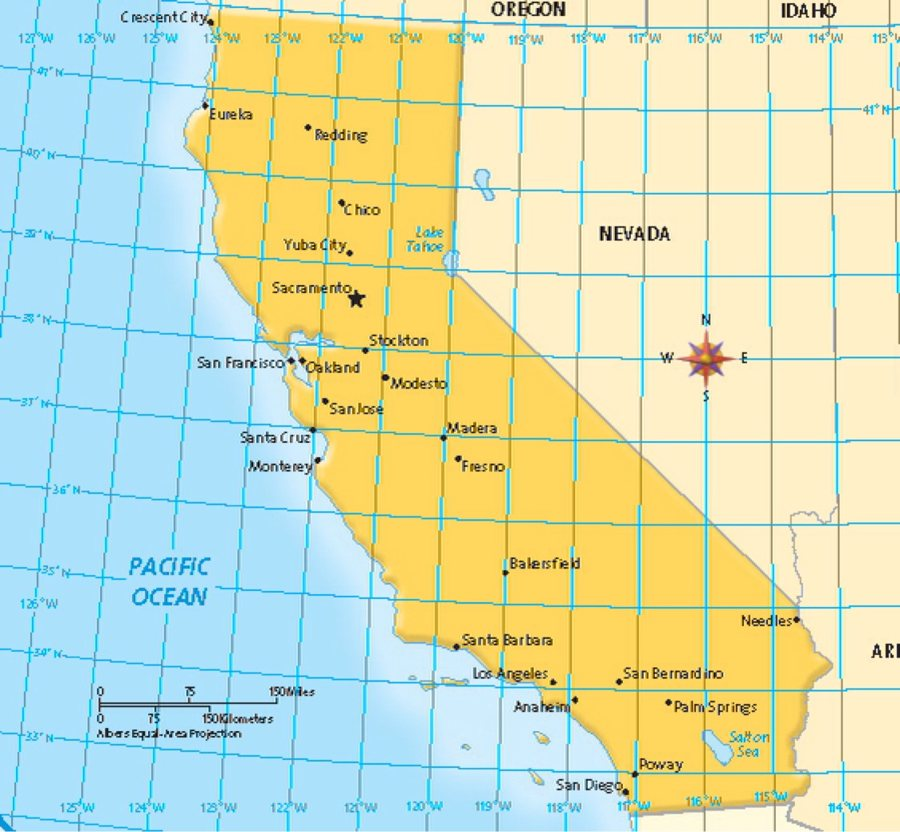

*Reference map 1 — an **Albers equal-area** projection.* It preserves areas, so the
latitude and longitude lines **curve and tilt**. Good for judging how big places are; bad
for reading coordinates off a scatter plot.

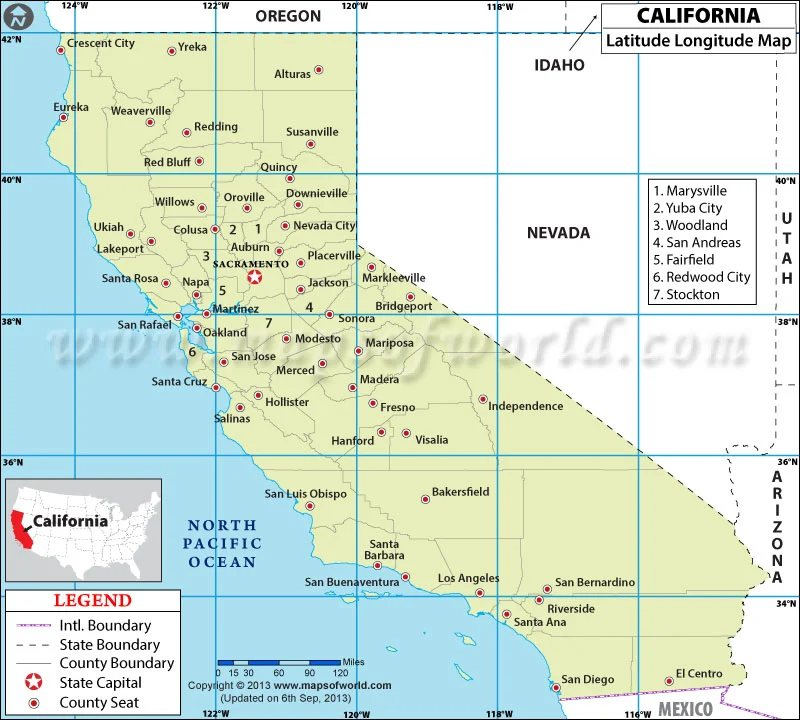

*Reference map 2 — a **latitude–longitude** map* (© mapsofworld.com, used for teaching).
Its grid lines are **straight and evenly spaced**, like the axes of a scatter plot. This is
the one that lines up with every map in this notebook: find San Francisco near 37.8°N,
122.4°W and Los Angeles near 34.1°N, 118.2°W, and you will find them in the same places
below.

Keep the diagonal in mind: the coast runs from the south-east (San Diego) to the
north-west (Crescent City). That single fact explains a great deal of what follows.

### Map A — the data draw California

Plot every block group at its coordinates and the data trace the shape of the state on
their own: there are no block groups in the ocean or in Nevada, because nobody lives there
in the census sense. Colour shows the median house value; marker size shows population.
The state outline and a dozen cities are added for orientation.

Two details make the map honest. The axes are **longitude and latitude**, exactly like the
straight-grid reference map; and the aspect ratio is corrected for latitude, because at
California's latitude a degree of longitude is only about 80% as long as a degree of
latitude.

In [10]:
outline = A.load_california_outline(use_live=USE_LIVE, verbose=True)

A.california_map(df, color="MedHouseVal", size="Population", outline=outline,
                 color_label="median value ($100k)",
                 title="Map A — every block group, coloured by median house value")

**Reading Map A.** Hover over any point to see its value.

* **The coast is expensive.** The yellow and green band hugs the Pacific almost the whole
  way down. Inland values fall away quickly.
* **Two clusters dominate:** the San Francisco Bay Area (with San Jose at its southern end)
  and the Los Angeles basin down towards San Diego.
* **The Central Valley is cheap** — the long corridor from Redding through Sacramento,
  Stockton and Fresno to Bakersfield.
* **The north and the east are sparse.** Few people live in the mountains and deserts, so
  there are few block groups to draw.

Where does the \$500,000 cap bite?

In [11]:
capped = df.assign(at_cap=(df.MedHouseVal >= 5.0).astype(float))
fig = A.california_map(capped.sort_values("at_cap"), color="at_cap", outline=outline,
                       colorscale=[[0, "#C9D2DB"], [0.5, "#C9D2DB"],
                                   [0.5, A.RED], [1, A.RED]],
                       showscale=False, marker_size=4,
                       title="Block groups at the $500,000 cap, in red")
fig

Almost entirely on the coast, and almost entirely in the two metropolitan clusters. So
**the places where location matters most are precisely the places where the data stop
recording how much it matters.** Every model below is trained on that truncated picture.

### ★ Deep dive — the same data on a street map

This version draws a sample of block groups over OpenStreetMap tiles, so you can zoom into
neighbourhoods. It needs an internet connection for the map background (no API key), and
is purely for exploration — skip it if you are offline.

In [12]:
try:
    fig = A.california_tilemap(df, color="MedHouseVal", n=5000,
                               title="A sample of block groups over OpenStreetMap")
    fig.show()
except Exception as exc:
    print("Street map unavailable here:", type(exc).__name__)

---
# Part 3 — Linear regression: explanation and interpretation

Linear regression predicts the target as a weighted sum of the features:

$$ y = \beta_0 + \beta_1\,\text{MedInc} + \beta_2\,\text{HouseAge} + \beta_3\,\text{AveRooms}
 + \beta_4\,\text{AveBedrms} + \beta_5\,\text{Population} + \beta_6\,\text{AveOccup}
 + \beta_7\,\text{Latitude} + \beta_8\,\text{Longitude} + \varepsilon $$

where

* $y$ is the median house value (in \$100,000s),
* $\beta_0$ is the intercept — the prediction when every feature equals zero,
* $\beta_j$ is the coefficient on feature $j$: the change in the prediction when that
  feature rises by one unit **and every other feature is held fixed**,
* $\varepsilon$ is the error — everything the eight features do not capture.

This is the archetype of an **interpretable-by-design** model: its whole mechanism is nine
numbers you can read. The lesson of this part is that *readable* is not the same as *easy
to read correctly*.

We fit it with `statsmodels`, which reports standard errors and p-values alongside the
coefficients, on the training set only.

In [13]:
ols = sm.OLS(ytr, sm.add_constant(Xtr)).fit()

print("=" * 72)
print("Linear regression on the training set")
print("=" * 72)
print(f"observations {int(ols.nobs):,} | R-squared {ols.rsquared:.4f} | "
      f"adjusted {ols.rsquared_adj:.4f} | RMSE {np.sqrt(ols.mse_resid):.4f}")
print(f"F-statistic {ols.fvalue:,.1f} (p-value {ols.f_pvalue:.2e})\n")
A.regression_table(ols)

Linear regression on the training set
observations 16,512 | R-squared 0.6023 | adjusted 0.6021 | RMSE 0.7257
F-statistic 3,124.2 (p-value 0.00e+00)



,coefficient,std error,t-stat,p-value,sig.
const,-36.9668,0.7408,-49.8993,0.0000,***
MedInc,0.4341,0.0047,92.2167,0.0000,***
HouseAge,0.0097,0.0005,19.3455,0.0000,***
AveRooms,-0.1049,0.0065,-16.0947,0.0000,***
AveBedrms,0.6281,0.0310,20.2691,0.0000,***
Population,-0.0000,0.0000,-0.5942,0.5524,
AveOccup,-0.0034,0.0005,-6.9428,0.0000,***
Latitude,-0.4237,0.0081,-52.3447,0.0000,***
Longitude,-0.4355,0.0085,-51.3943,0.0000,***


`ols.summary()` prints the full traditional table if you want it. The compact version above
has everything we need: each coefficient, its standard error, the t-statistic (coefficient
divided by standard error) and the p-value, with stars for conventional significance
levels.

### How to read a coefficient

A correct interpretation has four parts, and most published mistakes drop one of them:

1. **Units of the feature** — what does "one more unit" mean?
2. **Units of the target** — here \$100,000, so multiply every coefficient by 100,000 to
   get dollars.
3. **The *ceteris paribus* clause** — the effect holds *every other feature fixed*. With
   latitude and longitude in the model, that includes comparing block groups **at the same
   location**.
4. **Association, not causation** — the coefficient describes how the prediction moves, not
   what would happen if you intervened.

The next cell does steps 1 and 2 for you, so the dollar figures always match *your* fit.

In [14]:
per_unit = {"MedInc": "+$10,000 of median income", "HouseAge": "+1 year of median age",
            "AveRooms": "+1 room per household", "AveBedrms": "+1 bedroom per household",
            "Population": "+1,000 residents", "AveOccup": "+1 occupant per household",
            "Latitude": "+1 degree north (about 111 km)",
            "Longitude": "+1 degree east (about 89 km)"}
scale = {"Population": 1_000}

rows = []
for f, change in per_unit.items():
    b = ols.params[f] * scale.get(f, 1)
    rows.append({"feature": f, "change": change,
                 "effect on predicted median value": f"{b * 100_000:+,.0f} $",
                 "p-value": ols.pvalues[f]})
pd.DataFrame(rows).set_index("feature")

,change,effect on predicted median value,p-value
feature,,,
MedInc,"+$10,000 of median income","+43,406 $",0.0000
HouseAge,+1 year of median age,+966 $,0.0000
AveRooms,+1 room per household,"-10,493 $",0.0000
AveBedrms,+1 bedroom per household,"+62,815 $",0.0000
Population,"+1,000 residents",-316 $,0.5524
AveOccup,+1 occupant per household,-340 $,0.0000
Latitude,+1 degree north (about 111 km),"-42,371 $",0.0000
Longitude,+1 degree east (about 89 km),"-43,551 $",0.0000


### Interpretation of coefficients

Approximate figures are quoted below; the cell above shows the exact ones from your fit.

1. **Intercept (about −37.0).** The predicted value for a block group with zero income,
   zero rooms, zero people — at latitude 0°, longitude 0°, which is in the Gulf of Guinea
   off West Africa. It has no meaning as a prediction. Its *size*, though, is revealing, and
   section 3.1 explains where it comes from.

2. **`MedInc` (about +0.434).** Each extra \$10,000 of median household income is associated
   with roughly **\$43,400** more in median house value, holding the other seven features
   fixed. It is the most precisely estimated coefficient in the model (t around 90).

3. **`HouseAge` (about +0.0097).** Each extra year of median age is associated with about
   **\$970** more. Older neighbourhoods tend to be established, central and coastal, so this
   is not a claim that houses appreciate with age. And remember the top-code: "52" means
   "52 or older", so the model cannot see what happens beyond it.

4. **`AveRooms` (about −0.105) and 5. `AveBedrms` (about +0.63)** — read these together.
   Taken literally, one more room per household *lowers* the predicted value by about
   \$10,500, while one more bedroom *raises* it by about \$63,000. But the two features move
   together (correlation about 0.85), so "one more room, holding bedrooms fixed" describes a
   change the data barely contain, and "one more bedroom, holding rooms fixed" means
   converting an existing room into a bedroom. Neither is a renovation effect. Section 3.5
   shows that these are also among the least stable coefficients in the model.

6. **`Population` (a few hundred dollars per 1,000 residents).** Printed per person, the
   coefficient displays as **0.0000** — a *units* artefact, not a finding. Rescaled per
   1,000 residents it is small, and its p-value is far above conventional thresholds: we
   cannot distinguish it from zero. Always rescale before calling a coefficient "zero".

7. **`AveOccup` (about −0.003).** Taken at face value, one more occupant per household is
   associated with a few hundred dollars less. Section 3.2 shows why that number should not
   be taken at face value.

8. **`Latitude` (about −0.42).** One degree further north — about 111 km — is associated
   with roughly **\$42,000 less**, holding longitude fixed.

9. **`Longitude` (about −0.435).** Longitudes in California are negative, so a one-degree
   *increase* — say from −122 to −121 — means moving **east, inland**. That is associated
   with about **\$43,500 less**. Prices therefore *rise* towards the west, the coast.

Items 8 and 9 are hard to picture separately because the two coordinates are so strongly
correlated. Section 3.3 reads them together, and the picture becomes simple.

## 3.1 Where the intercept comes from

The intercept is always $\hat\beta_0 = \bar y - \sum_j \hat\beta_j \bar x_j$: whatever is
needed to make the fitted line pass through the averages. Here the coordinate terms are
huge, because latitude and longitude are large numbers — the average block group sits
around 35.6°N, 119.6°W — and the intercept has to absorb them.

In [15]:
b, mean_x = ols.params, Xtr.mean()
geo_at_mean = b.Latitude * mean_x.Latitude + b.Longitude * mean_x.Longitude
print(f"intercept                                    {b.const:+9.3f}")
print(f"latitude and longitude terms at the average  {geo_at_mean:+9.3f}")
print(f"the two together                             {b.const + geo_at_mean:+9.3f}")

centred = sm.OLS(ytr, sm.add_constant(Xtr - mean_x)).fit()
print(f"\nrefit on centred features: intercept = {centred.params.const:.4f}; "
      f"average house value = {ytr.mean():.4f}")
print("slopes unchanged:", np.allclose(centred.params.drop("const"), b.drop("const")))

intercept                                      -36.967
latitude and longitude terms at the average    +36.976
the two together                                +0.010

refit on centred features: intercept = 2.0691; average house value = 2.0691
slopes unchanged: True


The intercept and the coordinate terms very nearly cancel. **The intercept is not a
baseline at all: it exists to undo the arithmetic of feeding raw coordinates into a straight
line.** Subtract each feature's average first and the intercept becomes exactly the average
house value, while every slope stays the same. A meaningful intercept is a choice you make
when you set up the features.

## 3.2 One coefficient, decided by a handful of rows

Recall the extreme occupancy values from section 1.2. Ordinary least squares minimises
*squared* errors, so a point far from the rest pulls hard on the line — it has high
*leverage*. Refit the model after dropping the most extreme occupancy values, a sliver at a
time, and watch the `AveOccup` coefficient.

In [16]:
rows = []
for share in [0.0, 0.001, 0.0025, 0.005, 0.01, 0.02]:
    keep = Xtr.AveOccup <= Xtr.AveOccup.quantile(1 - share) if share else Xtr.AveOccup > -1
    fit = sm.OLS(ytr[keep], sm.add_constant(Xtr[keep])).fit()
    rows.append({"share of rows dropped (%)": 100 * share,
                 "rows dropped": int((~keep).sum()),
                 "AveOccup coefficient": fit.params.AveOccup,
                 "in dollars per occupant": f"{fit.params.AveOccup * 100_000:+,.0f}"})
trim = pd.DataFrame(rows)
display(trim)

fig = go.Figure(go.Scatter(x=trim["share of rows dropped (%)"],
                           y=trim["AveOccup coefficient"], mode="lines+markers",
                           line=dict(color=A.NAVY, width=3), marker=dict(size=9)))
A.layout(fig, "The AveOccup coefficient as the most extreme rows are removed", height=400,
         xaxis_title="share of training rows dropped (%)",
         yaxis_title="AveOccup coefficient")

,share of rows dropped (%),rows dropped,AveOccup coefficient,in dollars per occupant
0,0.0000,0,-0.0034,-340
1,0.1000,17,-0.3096,"-30,957"
2,0.2500,42,-0.3587,"-35,872"
3,0.5000,83,-0.3825,"-38,248"
4,1.0000,166,-0.4071,"-40,710"
5,2.0000,331,-0.4352,"-43,524"


Removing a tenth of one per cent of the training data — fewer than twenty block groups
out of more than sixteen thousand — changes the coefficient by a factor of roughly
ninety. After that it settles.

So which number is "the" effect of occupancy? Neither, as a fact about housing. The
full-data coefficient is dominated by a few block groups with implausible occupancy; the
trimmed one describes the rest. **An OLS coefficient is an average slope, and extreme rows
can own it.** A coefficient table with standard errors gives no hint of this — the
full-data estimate is highly "significant" either way.

## 3.3 Latitude and longitude, read together

Because California is diagonal, "one degree north *holding longitude fixed*" asks about a
move the state's geography rarely offers. So ask instead about the two moves that matter:
**along the coast** (north-west) and **towards the coast** (south-west).

In [17]:
along = b.Latitude * (+1) + b.Longitude * (-1)     # 1 degree north AND 1 degree west
toward = b.Latitude * (-1) + b.Longitude * (-1)    # 1 degree south AND 1 degree west
print(f"1 degree north-west, ALONG the coast:     {along * 100_000:+10,.0f} $")
print(f"1 degree south-west, TOWARDS the coast:   {toward * 100_000:+10,.0f} $")

1 degree north-west, ALONG the coast:         +1,181 $
1 degree south-west, TOWARDS the coast:      +85,922 $


The picture is now simple. Moving along the coast changes the prediction by very little;
moving towards it adds a great deal. **The linear model has learnt, in effect, distance
from the coast**, with lines of equal predicted value running roughly parallel to the
shoreline.

That is a genuinely sensible finding — and note that it was invisible in the two separate
coefficients, each of which looked like a statement about north or east.

### ★ Deep dive — rotate the coordinates

<details>
<summary><b>The mathematics</b> — a rotation that removes most of the collinearity</summary>

Define two new coordinates by rotating latitude and longitude through 45°:

$$ u = \frac{\text{lat} - \text{lon}}{\sqrt 2} \quad(\text{along the coast, north-west}),
\qquad v = -\frac{\text{lat} + \text{lon}}{\sqrt 2} \quad(\text{towards the coast,
south-west}). $$

A rotation changes nothing about the fit: the predictions and $R^2$ are identical, because
any linear function of (lat, lon) is also a linear function of $(u, v)$. What changes is
what the coefficients *mean*. Now each one answers a question the geography actually
poses, and $u$ and $v$ are far less correlated than latitude and longitude.

A caution on units: a degree of longitude is shorter than a degree of latitude
(about 89 km against 111 km at 37°N), so moves measured "in degrees" are not quite moves of
equal distance. It does not change the conclusion.
</details>

In [18]:
u = (Xtr.Latitude - Xtr.Longitude) / np.sqrt(2)
v = -(Xtr.Latitude + Xtr.Longitude) / np.sqrt(2)
Xrot = Xtr.drop(columns=["Latitude", "Longitude"]).assign(AlongCoast=u, TowardCoast=v)
rot = sm.OLS(ytr, sm.add_constant(Xrot)).fit()

print(f"R-squared, original coordinates {ols.rsquared:.6f} | rotated {rot.rsquared:.6f}")
print(f"correlation: latitude-longitude {Xtr.Latitude.corr(Xtr.Longitude):+.3f} | "
      f"along-toward {u.corr(v):+.3f}\n")
A.regression_table(rot).loc[["AlongCoast", "TowardCoast"]]

R-squared, original coordinates 0.602303 | rotated 0.602303
correlation: latitude-longitude -0.925 | along-toward -0.167



,coefficient,std error,t-stat,p-value,sig.
AlongCoast,0.0083,0.0020,4.1258,0.0000,***
TowardCoast,0.6076,0.0115,52.6354,0.0000,***


Identical fit; far weaker collinearity; and two coefficients that say what section 3.3 said
in words. The along-coast effect is small — economically negligible, though with sixteen
thousand rows even a small effect is statistically detectable — while the towards-coast
effect is large and very precisely estimated.

### Map B — the linear model's California

What does the fitted model imply about location across the whole state? Hold every other
feature at its average and let only the coordinates vary. The contribution of location is
then $\hat\beta_{\text{lat}}(\text{lat} - \overline{\text{lat}}) +
\hat\beta_{\text{lon}}(\text{lon} - \overline{\text{lon}})$ — a flat, tilted plane.

In [19]:
lons = np.linspace(-124.5, -114.0, 120)
lats = np.linspace(32.4, 42.1, 120)
LON, LAT = np.meshgrid(lons, lats)
plane = b.Latitude * (LAT - mean_x.Latitude) + b.Longitude * (LON - mean_x.Longitude)

A.california_contour(lons, lats, plane, colorscale="RdBu_r", zmid=0,
                     colorbar_title="$100k vs average", outline=outline,
                     districts=Xtr.sample(4000, random_state=SEED),
                     title="Map B — what a linear model can say about location")

Straight, parallel contours, running roughly along the coast: blue inland, red towards the
ocean. It is a respectable first approximation of Map A.

It is also **the only shape a linear model can draw.** A plane has one direction of
steepest rise. It cannot represent two separate hot spots — the Bay Area *and* Los Angeles —
with cheaper land between them, however much data you give it. Keep this map beside you;
in Part 9 the black box draws something very different.

## 3.4 Using the model for predictions

A coefficient table is also a calculator. The 2025 version of this notebook substituted the
following values into the fitted equation:

`MedInc` = 5, `HouseAge` = 20, `AveRooms` = 6, `AveBedrms` = 1, `Population` = 1,000,
`AveOccup` = 3, `Latitude` = 34, `Longitude` = −118

— a block group of above-average income near Los Angeles. The next cell evaluates it with
this notebook's coefficients, and with the coefficients printed in the 2025 version, which
were estimated on a different sample (more on that in section 3.5).

In [20]:
x0 = pd.Series({"MedInc": 5, "HouseAge": 20, "AveRooms": 6, "AveBedrms": 1,
                "Population": 1000, "AveOccup": 3, "Latitude": 34, "Longitude": -118})

yhat = b.const + (b.drop("const") * x0).sum()
print(f"this notebook's coefficients: {yhat:.3f}  ->  about ${yhat * 100_000:,.0f}")

coef_2025 = pd.Series({"const": -37.9201, "MedInc": 0.4256, "HouseAge": 0.0103,
                       "AveRooms": -0.1161, "AveBedrms": 0.6638, "Population": 0.0,
                       "AveOccup": -0.2610, "Latitude": -0.4673, "Longitude": -0.4627})
y25 = coef_2025.const + (coef_2025.drop("const") * x0).sum()
print(f"2025 coefficients:           {y25:.3f}  ->  about ${y25 * 100_000:,.0f}")

this notebook's coefficients: 2.367  ->  about $236,653
2025 coefficients:           2.309  ->  about $230,850


Similar predictions from noticeably different coefficients — which is the next section's
subject. Note the unit conversion on the way out: 2.37 means about \$237,000, not \$2.37
thousand.

## ★ 3.5 How stable is an interpretation?

The 2025 version of this notebook fitted the regression on a random sample of 1,000 block
groups. Its `AveOccup` coefficient was −0.261, which reads as "\$26,100 less per extra
occupant" — about seventy-five times the full-data figure.

Neither version made an arithmetic mistake. Refit the model on 200 different random samples
of 1,000 block groups and see how much each coefficient moves. The red diamond marks the
2025 value; the dark line marks the full training-set value.

In [21]:
draws = []
for s in range(200):
    idx = np.random.RandomState(s).choice(len(Xtr), 1000, replace=False)
    draws.append(sm.OLS(ytr.iloc[idx], sm.add_constant(Xtr.iloc[idx])).fit().params)
draws = pd.DataFrame(draws)

from plotly.subplots import make_subplots
feats = list(X.columns)
fig = make_subplots(rows=2, cols=4, subplot_titles=feats, horizontal_spacing=0.07,
                    vertical_spacing=0.16)
for k, f in enumerate(feats):
    r, c = k // 4 + 1, k % 4 + 1
    fig.add_trace(go.Box(y=draws[f], name=f, marker_color=A.BLUE, boxpoints="outliers",
                         showlegend=False), row=r, col=c)
    fig.add_trace(go.Scatter(x=[f], y=[coef_2025[f]], mode="markers", showlegend=False,
                             marker=dict(symbol="diamond", size=12, color=A.RED)),
                  row=r, col=c)
    fig.add_hline(y=b[f], line=dict(color=A.NAVY, width=2), row=r, col=c)
    fig.add_hline(y=0, line=dict(color="#BBBBBB", width=1, dash="dot"), row=r, col=c)
fig.update_xaxes(showticklabels=False)
A.layout(fig, "200 regressions on 1,000 random block groups each", height=620)

In [22]:
stability = pd.DataFrame({
    "full training set": b.drop("const"),
    "mean of 200 samples": draws[feats].mean(),
    "sd of 200 samples": draws[feats].std(),
    "sign differs from full set (%)": [100 * (np.sign(draws[f]) != np.sign(b[f])).mean()
                                       for f in feats]})
stability

,full training set,mean of 200 samples,sd of 200 samples,sign differs from full set (%)
MedInc,0.4341,0.4353,0.0341,0.0000
HouseAge,0.0097,0.0102,0.0023,0.0000
AveRooms,-0.1049,-0.1141,0.0477,1.0000
AveBedrms,0.6281,0.7191,0.2673,1.0000
Population,-0.0000,0.0000,0.0000,76.0000
AveOccup,-0.0034,-0.1748,0.1312,4.5000
Latitude,-0.4237,-0.4300,0.0369,0.0000
Longitude,-0.4355,-0.4327,0.0371,0.0000


Read the last two columns.

* **`MedInc`, `Latitude` and `Longitude` are rock-solid**: every sample tells the same
  story.
* **`AveOccup`** swings widely, and its *sign* occasionally flips. Samples that happen to
  miss the extreme rows of section 3.2 give a steep negative slope; samples that include
  one give almost none.
* **`AveRooms` and `AveBedrms`** are unstable too: across samples, each one's spread is
  roughly two-fifths of its average size — what you would expect of two collinear
  features that both contain extreme values.
* **`Population`** changes sign often — as you would expect of a coefficient that is
  statistically indistinguishable from zero.

The 2025 values sit comfortably inside these distributions. They were not wrong; they were
**one draw**. An interpretation is only as stable as the coefficient it interprets, and the
standard error of a single fit does not always warn you — leverage, in particular, hides
from it.

### What Part 3 established

* An interpretable model still has to be *interpreted*, and each step — units, the
  *ceteris paribus* clause, correlated features — is a place to go wrong.
* Some coefficients are facts about the data; others are facts about a handful of rows.
* Read correlated features **together**: the coordinates made sense only as "along" and
  "towards" the coast.
* A linear model can only say that location is a tilted plane.

Part 4 turns these coefficients into the language used for every other model.

---
# Part 4 — From coefficients to SHAP

It is important to be able to explain the output of *any* machine learning model, not just
a linear one. **SHAP** (SHapley Additive exPlanations; Lundberg and Lee, 2017) is the most
widely used way of doing it. For a single prediction it tells you how much each feature
contributed, and its contributions are **additive**: they sum exactly to the prediction.
It can be applied to any model — linear regression, random forests, gradient boosting,
neural networks — because it needs only the ability to evaluate the model on modified inputs.

### A bit of history

SHAP rests on the **Shapley value** from cooperative game theory, named after Lloyd Shapley,
who introduced it in a 1951 RAND memorandum and published it in 1953. Shapley shared the
2012 Nobel Memorial Prize in Economic Sciences with Alvin Roth — though the prize was for
*stable allocations and the practice of market design*, the matching theory behind
kidney-exchange and school-choice systems, not for the value we are about to use.

### The cooperative game

Imagine the features of one block group as **players** in a game. The **game** is the
model; the **payout** is the prediction. Together the players produce the payout, and the
question is how to credit each one fairly.

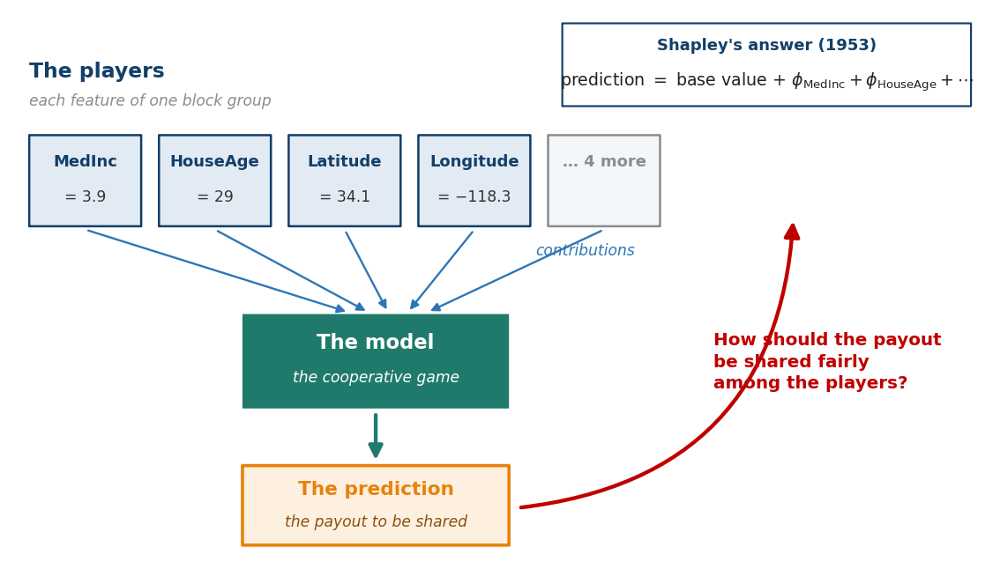

Fairness needs a definition, and Shapley gave it as four axioms:

* **Efficiency** — the credits add up exactly to the payout: the contributions sum to the
  prediction minus the base value. Nothing is left over, nothing is invented.
* **Symmetry** — two players who contribute identically to every possible coalition
  receive identical credit.
* **Dummy (null player)** — a player who never changes the payout of any coalition receives
  zero.
* **Additivity** — if the game is the sum of two games, each player's credit is the sum of
  their credits in the two. For a model built as a sum of trees, this is what lets SHAP
  explain each tree separately and add the results.

Shapley proved that **exactly one** way of dividing the payout satisfies all four. That
uniqueness is why the method won.

### The formula

For a model $f$ with $p$ features, the Shapley value of feature $j$ is its marginal
contribution averaged over every possible coalition $S$ of the other features:

$$ \phi_j \;=\; \sum_{S \subseteq N \setminus \{j\}}
\frac{|S|!\,(p-|S|-1)!}{p!}\,\Big[v\big(S \cup \{j\}\big) - v(S)\Big] $$

The weights have a friendly reading: **list the features in every possible order, and
average the change each feature makes at the moment it joins the list.**

Everything depends on $v(S)$, the *value* of a coalition — "what does the model predict if
it knows only the features in $S$?" A model cannot run with features missing, so we fill
them in by averaging over a **background** sample of real block groups:

$$ v(S) \;=\; \frac{1}{|B|}\sum_{b \in B} f\big(x_S,\; b_{\bar S}\big) $$

— features in $S$ take this block group's values; the rest take the background's. That
choice of background is an analyst's decision, and a different choice gives different
numbers. The lecture slide *SHAP, stated honestly* is about exactly this.

## 4.1 A Shapley value by hand

Formulas are easier to trust once you have watched one work. We fit a small gradient-boosting
model on just **three** features — `MedInc`, `Latitude`, `Longitude` — so that there are only
$2^3 = 8$ coalitions and $3! = 6$ orderings, and compute the Shapley values of one block
group ourselves.

Our block group, here and for the rest of the notebook, is the test-set block group
**closest to downtown San Francisco**.

In [23]:
sf_lat, sf_lon = A.CA_CITIES["San Francisco"]
dist = np.hypot(Xte.Latitude - sf_lat,
                (Xte.Longitude - sf_lon) * np.cos(np.radians(sf_lat)))
i = int(np.argmin(dist.values))          # position of our block group in the test set
print(f"our block group: test-set position {i}, "
      f"{Xte.iloc[i].Latitude:.2f}\u00b0N {Xte.iloc[i].Longitude:.2f}\u00b0, "
      f"actual median value ${yte.iloc[i] * 100_000:,.0f}")

three = ["MedInc", "Latitude", "Longitude"]
small = HistGradientBoostingRegressor(max_iter=200, max_depth=3, learning_rate=0.1,
                                      early_stopping=False,
                                      random_state=SEED).fit(Xtr[three], ytr)
background = Xtr[three].sample(100, random_state=SEED)
x_i = Xte[three].iloc[[i]]
print(f"three-feature model predicts {small.predict(x_i)[0]:.3f} for it")

our block group: test-set position 37, 37.77°N -122.42°, actual median value $350,000
three-feature model predicts 3.092 for it


**Step 1 — the value of every coalition.** For each subset of the three features, give the
100 background block groups *our* values for those features, predict, and average.

In [24]:
from itertools import combinations, permutations


def value(coalition):
    Z = background.copy()
    for f in coalition:
        Z[f] = x_i[f].values[0]
    return float(small.predict(Z).mean())


coalitions = [c for r in range(4) for c in combinations(three, r)]
v = {c: value(c) for c in coalitions}
pd.DataFrame({"coalition S": [", ".join(c) if c else "(empty) -- the base value"
                              for c in coalitions],
              "v(S)": [v[c] for c in coalitions]}).set_index("coalition S")

,v(S)
coalition S,
(empty) -- the base value,1.9358
MedInc,1.6069
Latitude,1.4675
Longitude,4.1941
"MedInc, Latitude",1.1339
"MedInc, Longitude",3.9063
"Latitude, Longitude",3.5124
"MedInc, Latitude, Longitude",3.0920


**Step 2 — every ordering.** Add the features one at a time, in each of the six possible
orders, and record how much each one changes the value when it joins.

In [25]:
rows = []
for order in permutations(three):
    row = {"order of arrival": " \u2192 ".join(order)}
    for k, f in enumerate(order):
        before = tuple(sorted(order[:k], key=three.index))
        after = tuple(sorted(order[:k + 1], key=three.index))
        row[f] = v[after] - v[before]
    rows.append(row)
orderings = pd.DataFrame(rows).set_index("order of arrival")
phi_hand = orderings.mean()
display(orderings)
print("Shapley value = the average of each column:")
print(phi_hand.round(4).to_string())

,MedInc,Latitude,Longitude
order of arrival,,,
MedInc → Latitude → Longitude,-0.3289,-0.4729,1.9581
MedInc → Longitude → Latitude,-0.3289,-0.8143,2.2994
Latitude → MedInc → Longitude,-0.3336,-0.4682,1.9581
Latitude → Longitude → MedInc,-0.4204,-0.4682,2.0449
Longitude → MedInc → Latitude,-0.2878,-0.8143,2.2583
Longitude → Latitude → MedInc,-0.4204,-0.6817,2.2583


Shapley value = the average of each column:
MedInc      -0.3534
Latitude    -0.6199
Longitude    2.1295


**Step 3 — check against the library, and check efficiency.** `shap` with the exact
algorithm and the same background should reproduce our numbers, and the three values
should sum to the prediction minus the base value.

In [26]:
exact = shap.Explainer(small.predict, background, algorithm="exact")(x_i)
check = pd.DataFrame({"by hand": phi_hand, "shap, exact": exact.values[0]})
check["difference"] = check["by hand"] - check["shap, exact"]
display(check)
print(f"efficiency: v(all three) - v(empty) = {v[tuple(three)] - v[()]:.4f}; "
      f"sum of Shapley values = {phi_hand.sum():.4f}")

ExactExplainer explainer: 2it [00:14, 14.64s/it]               


,by hand,"shap, exact",difference
MedInc,-0.3534,-0.3534,-0.0000
Latitude,-0.6199,-0.6199,-0.0000
Longitude,2.1295,2.1295,0.0000


efficiency: v(all three) - v(empty) = 1.1562; sum of Shapley values = 1.1562


Identical, to rounding error. There is no magic inside `shap` — only this averaging, done
efficiently.

Look at the orderings table once more. A feature's contribution **depends on who arrived
before it**: latitude, in particular, is worth very different amounts depending on whether
longitude is already known. That dependence is an *interaction*, and averaging over all
orderings is Shapley's way of sharing its credit fairly. It is also why latitude and
longitude often carry large contributions of opposite sign — the model has learnt location
as a *combination* of the two, and neither coordinate means much on its own.

## 4.2 The bridge: SHAP for a linear model

Now the result that connects Part 3 to everything that follows.

<details>
<summary><b>The mathematics</b> — why SHAP equals coefficient × deviation for a linear
model</summary>

Let $f(x) = \beta_0 + \sum_k \beta_k x_k$. With the background-average definition of
$v(S)$, the features outside $S$ contribute their background means:

$$ v(S) = \beta_0 + \sum_{k \in S}\beta_k x_k + \sum_{k \notin S}\beta_k\,\bar x_k . $$

Adding feature $j$ to *any* coalition changes the value by the same amount,

$$ v(S \cup \{j\}) - v(S) = \beta_j\,(x_j - \bar x_j), $$

so the average over coalitions is that same amount:

$$ \boxed{\;\phi_j = \beta_j\,(x_j - \bar x_j)\;} $$

With no interactions, the order of arrival never matters.
</details>

For a linear model, **a SHAP value is simply the coefficient times how far this block group
sits from the average.** Everything you learnt about reading coefficients in Part 3 is
therefore already a lesson about SHAP. Let us check it numerically, using `shap`'s general
algorithm — which knows nothing about linearity. It evaluates every coalition for every
test block group, so expect a progress bar for around twenty seconds.

In [27]:
lin = LinearRegression().fit(Xtr, ytr)
print("same coefficients as statsmodels:",
      np.allclose(lin.coef_, ols.params.drop("const").values))

bg = shap.utils.sample(Xtr, 100, random_state=SEED)     # background: 100 block groups
explainer_lin = shap.Explainer(lin.predict, bg)
sv_lin = explainer_lin(Xte)

by_formula = lin.coef_ * (Xte.values - bg.values.mean(axis=0))
print(f"largest |SHAP - coefficient x (value - mean)| over {len(Xte):,} block groups: "
      f"{np.abs(sv_lin.values - by_formula).max():.1e}")

same coefficients as statsmodels: True


ExactExplainer explainer: 4129it [00:28, 101.41it/s]                          


largest |SHAP - coefficient x (value - mean)| over 4,128 block groups: 3.2e-09


Equal to numerical precision. SHAP *generalises* "coefficient × deviation from average" to
models that have no coefficients. When the model is not linear, the order of arrival starts
to matter and the simple formula breaks — which is exactly the case SHAP was built for.

## 4.3 Seeing it: the native SHAP partial dependence plot

To understand a feature's role you need two things: **how changing it changes the model's
output**, and **how its values are distributed**. `shap.partial_dependence_plot` shows
both. Read it like this:

* The **blue line** is the partial dependence: the average prediction when every background
  block group is given this value of `MedInc`. The $y$-axis is $E[f(x) \mid \text{MedInc}]$
  — read it as "the expected median house value given the level of median income".
* The **grey histogram** along the bottom shows how `MedInc` is distributed.
* The **horizontal grey line** is the model's average prediction, $E[f(x)]$; the
  **vertical grey line** is the average of `MedInc`. The blue line always passes through
  their intersection — think of it as the *centre* of the plot.
* The **red bar** is our San Francisco block group's SHAP value for `MedInc`: the vertical
  distance from the average prediction, drawn at its own income.

For a linear model the red bar ends exactly on the blue line — that is the identity of
section 4.2, drawn.

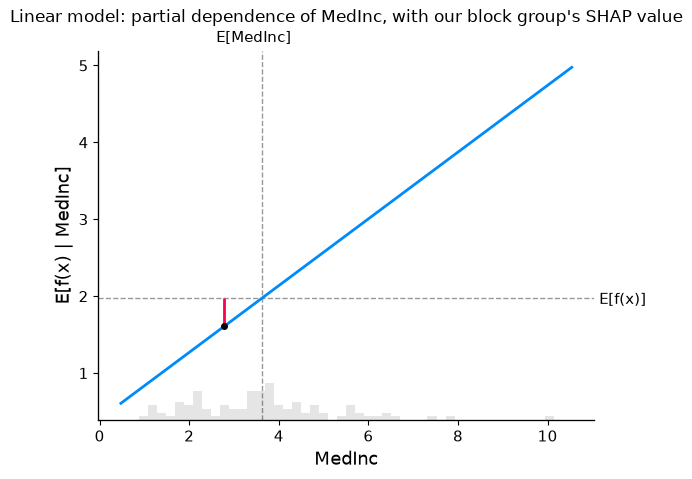

In [28]:
shap.partial_dependence_plot(
    "MedInc", lin.predict, bg,
    ice=False, model_expected_value=True, feature_expected_value=True,
    shap_values=sv_lin[i:i + 1, :], show=False)
plt.title("Linear model: partial dependence of MedInc, with our block group's SHAP value")
plt.show()

### Adding ICE lines

The `ice` option adds **Individual Conditional Expectation** lines.

*Without ICE* (`ice=False`) you see only the average effect of `MedInc` — one line, easy to
read, but it hides individual variation.

*With ICE* (`ice=True`) every thin line shows how the prediction for **one** block group
would change if only its `MedInc` changed; the bold line is still the average. ICE helps
you see how much block groups differ, whether the relationship is consistent across them,
and — through lines with different slopes — interactions with other features.

Think of it as the difference between "on average, higher income means higher prices" and
"here is how *each* block group's price would respond to income, and here is the average".

For a linear model, what should the ICE lines look like? Predict before you run the cell.

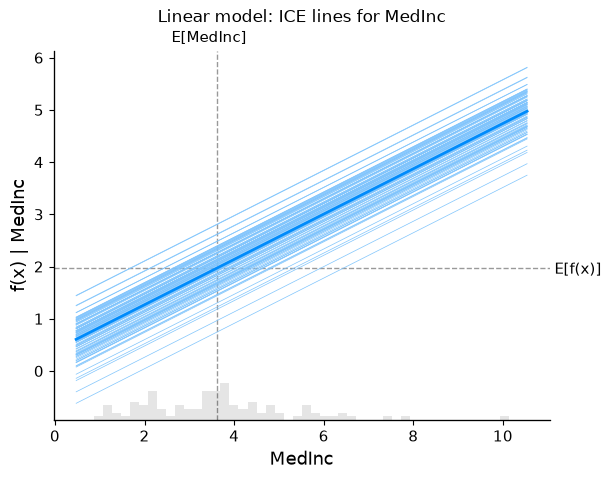

In [29]:
shap.partial_dependence_plot(
    "MedInc", lin.predict, bg,
    ice=True, model_expected_value=True, feature_expected_value=True, show=False)
plt.title("Linear model: ICE lines for MedInc")
plt.show()

Perfectly parallel. In a linear model income adds the same amount everywhere, so no line
can have a different slope. Hold that image: in Part 7 the same plot for the boosted
model looks nothing like it.

### SHAP scatter and waterfall — native, then Plotly

The **scatter plot** puts each block group's SHAP value for `MedInc` on the $y$-axis
against its `MedInc` on the $x$-axis. Positive SHAP values push the prediction up, negative
ones pull it down. For a linear model the points must lie on a single straight line whose
slope is the coefficient.

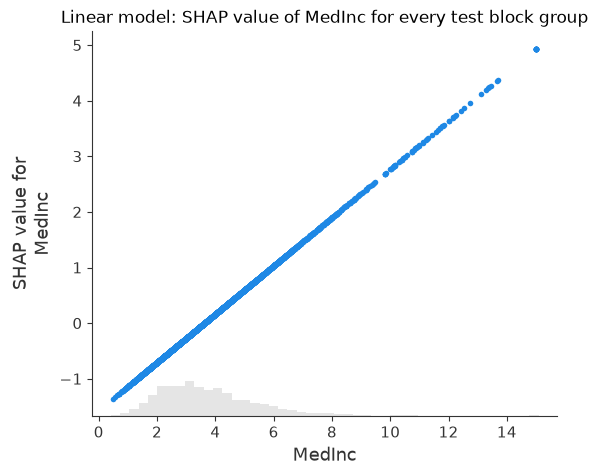

In [30]:
shap.plots.scatter(sv_lin[:, "MedInc"], show=False)
plt.title("Linear model: SHAP value of MedInc for every test block group")
plt.show()

In [31]:
A.plot_dependence(sv_lin, Xte, "MedInc",
                  title="The same plot in Plotly \u2014 hover to read any block group")

The **waterfall plot** explains a single prediction. It starts at the **base value** —
the model's average prediction over the background — at the bottom, and adds each
feature's SHAP value in turn, largest first, until it arrives at the prediction for this
block group, $f(x)$, at the top. Positive contributions (red in the native plot) push up;
negative ones (blue) pull down.

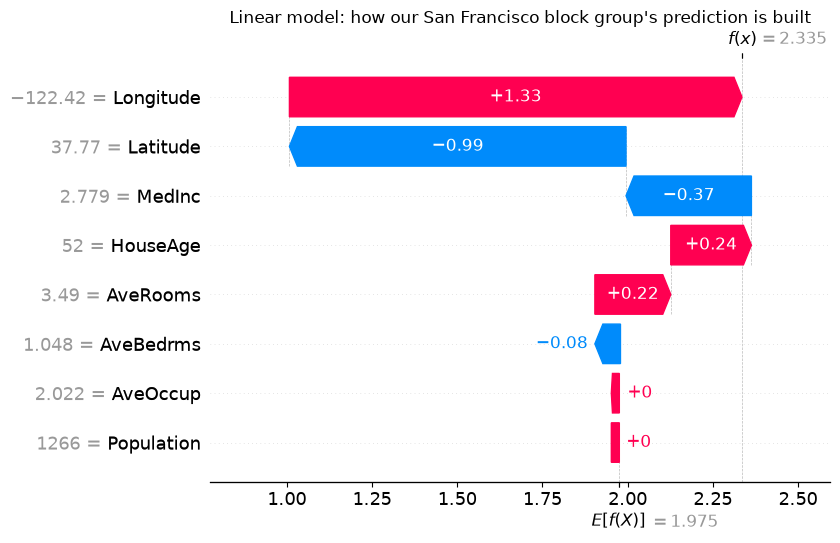

In [32]:
shap.plots.waterfall(sv_lin[i], max_display=10, show=False)
plt.title("Linear model: how our San Francisco block group's prediction is built")
plt.show()

In [33]:
A.plot_waterfall(sv_lin.values[i], sv_lin.base_values[i], X.columns, Xte.iloc[i].values,
                 value_label="predicted median value ($100k)",
                 title="The same waterfall in Plotly (read left to right)")

**Native or Plotly?** They carry the same numbers. The native plots are the canonical
forms — what you will meet in papers, documentation and other people's code — so you need
to read them fluently. The Plotly versions add hover values, zoom, and the lecture's colour
scheme, and they are what we use when a plot has to be combined with a map. From here on we
show both where both add something.

Notice, in the waterfall, how large the latitude and longitude contributions are for a
San Francisco block group — and remember that, for a linear model, each is just a
coefficient times a distance from the average location.

---
# Part 5 — A black box: gradient boosting

We now extend the analysis to **gradient boosting**, which builds a prediction by adding up
hundreds of small decision trees, each correcting the errors of those before it. It
captures non-linear relationships and interactions between features that a linear model
cannot — at the cost of having no coefficients to read.

We use scikit-learn's `HistGradientBoostingRegressor`, the same model family as Labs A and
B. You may know the algorithm by other names: **XGBoost** and **LightGBM** are separately
installed implementations of the same idea — the 2025 version of this notebook used
XGBoost — and SHAP explains all of them in the same way. scikit-learn's version needs no
extra compiled library, which keeps the notebook dependable across computers.

One setting deserves a word. By default, this model quietly holds back a tenth of the
training data to decide when to stop adding trees. We switch that off
(`early_stopping=False`) so that every training row is used — which is what lets Part 8
check, exactly, that SHAP's base value equals the average prediction on the training data.

Why SHAP matters for a model like this:

1. **Non-linearity and interactions.** The effect of a feature can depend on its own level
   and on other features; SHAP credits each prediction accordingly.
2. **Feature importance.** Averaging SHAP values ranks the features the model relies on.
3. **Individual explanations.** SHAP explains *each* prediction, which is what regulators
   and customers ask for in finance.
4. **Standard visual tools** — dependence, summary, force and waterfall plots — that make
   findings easier to communicate.

> **Evaluate before you explain.** A feature that looks unimportant for a *bad* model may be
> crucial for a *good* one. Always check a model's performance on held-out data before
> computing any importance or explanation — otherwise you are carefully explaining an
> artefact.

In [34]:
gbm = HistGradientBoostingRegressor(max_iter=500, max_depth=4, learning_rate=0.05,
                                    early_stopping=False, random_state=SEED).fit(Xtr, ytr)

perf = pd.DataFrame({
    "training R\u00b2": [r2_score(ytr, lin.predict(Xtr)), r2_score(ytr, gbm.predict(Xtr))],
    "test R\u00b2": [r2_score(yte, lin.predict(Xte)), r2_score(yte, gbm.predict(Xte))],
    "test RMSE ($)": [np.sqrt(mean_squared_error(yte, lin.predict(Xte))) * 100_000,
                      np.sqrt(mean_squared_error(yte, gbm.predict(Xte))) * 100_000],
}, index=["linear regression", "gradient boosting"])
perf.style.format({"training R\u00b2": "{:.3f}", "test R\u00b2": "{:.3f}",
                   "test RMSE ($)": "{:,.0f}"})

,training R²,test R²,test RMSE ($)
linear regression,0.602,0.621,"71,877"
gradient boosting,0.870,0.840,"46,687"


The black box explains about 84% of the variation in held-out house values, against about
62% for the linear model, and its typical error is about \$25,000 smaller.
Here, opacity buys real accuracy. **Remember this**: in `Lec09a` the same comparison on
mortgage decisions comes out very differently. The accuracy premium is a property of a
dataset, not a law.

The gap between training and test $R^2$ for the boosted model is modest, so it has not simply
memorised the training data.

### ★ Deep dive — predicted against actual

A model trained on censored data inherits the censoring. Look at the top edge.

In [35]:
fig = go.Figure()
for name, model, colour in [("linear regression", lin, A.GREY),
                            ("gradient boosting", gbm, A.NAVY)]:
    fig.add_trace(go.Scattergl(x=yte, y=model.predict(Xte), mode="markers", name=name,
                               marker=dict(size=3.5, color=colour, opacity=0.35)))
fig.add_trace(go.Scatter(x=[0, 5.2], y=[0, 5.2], mode="lines", name="perfect prediction",
                         line=dict(color=A.RED, dash="dash")))
A.layout(fig, "Predicted against actual on the test set ($100k)", height=560,
         xaxis_title="actual median value", yaxis_title="predicted median value")

The vertical column of points at an actual value of 5 is the \$500,000 cap: block groups
whose true values range far above it, all recorded as 5, and predicted anywhere from
\$250,000 upwards. The linear model also predicts impossible values — some negative —
because a straight line does not know that prices cannot fall below zero.

---
# Part 6 — Global explanation: what does the model use overall?

## 6.1 Permutation importance

**Permutation importance** asks a simple question: *if I scramble one feature, how much
worse does the model get?* It is **model-agnostic** (it works for any model) and **global**
(it describes the model as a whole, not one prediction).

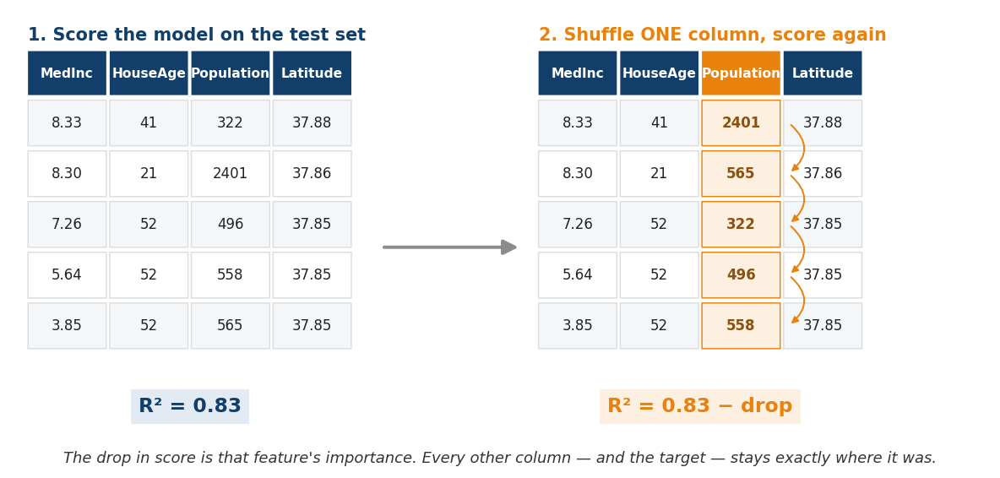

The procedure:

1. Take a trained model and score it on the test set.
2. Randomly shuffle the values in **one** column of the test set, leaving the target and
   every other column in place, and score the model again. The drop in score measures how
   much the model depends on that feature.
3. Put the column back and repeat for the next feature.

Steps 2 and 3 are repeated several times with different shuffles, which gives a sense of
the uncertainty. The reasoning is that shuffling removes a feature's information while
keeping its distribution: if the model relied on it, performance should suffer.

scikit-learn's `permutation_importance` does this for us. We give it the model, the test
set, the number of repeats, and the score to use — here $R^2$, so importance is measured as
a **drop in $R^2$**.

In [36]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(gbm, Xte, yte, n_repeats=10, random_state=SEED,
                              scoring="r2", n_jobs=2)
baseline = r2_score(yte, gbm.predict(Xte))
lat_after = baseline - perm.importances_mean[list(X.columns).index("Latitude")]
print(f"test R\u00b2 {baseline:.3f}; with Latitude shuffled it falls to about {lat_after:.2f}")

A.plot_permutation_importance(perm, list(X.columns),
                              title="Permutation importance on the test set (10 shuffles each)")

test R² 0.840; with Latitude shuffled it falls to about -0.54


The features at the top matter most; the spread of points shows how much the answer varies
between shuffles.

Look at the size of the top bars. Shuffling latitude alone pushes $R^2$ *below zero* — the
model becomes worse than predicting the average everywhere. That is more than "latitude is
important". Latitude and longitude are strongly correlated, so shuffling one of them breaks
the pairing and creates block groups at impossible locations: San Francisco's longitude
with San Diego's latitude, somewhere in the Pacific. The model is then asked about places
it has never seen. **Permutation importance for correlated features partly measures how
badly the model extrapolates** — the same off-the-data problem we meet again in Part 7.

## 6.2 Global SHAP: bar and beeswarm

A different route to a global ranking: compute SHAP values for every test block group and
average their absolute size. For tree models `shap.TreeExplainer` computes them exactly and
quickly.

SHAP values: 4,128 block groups x 8 features


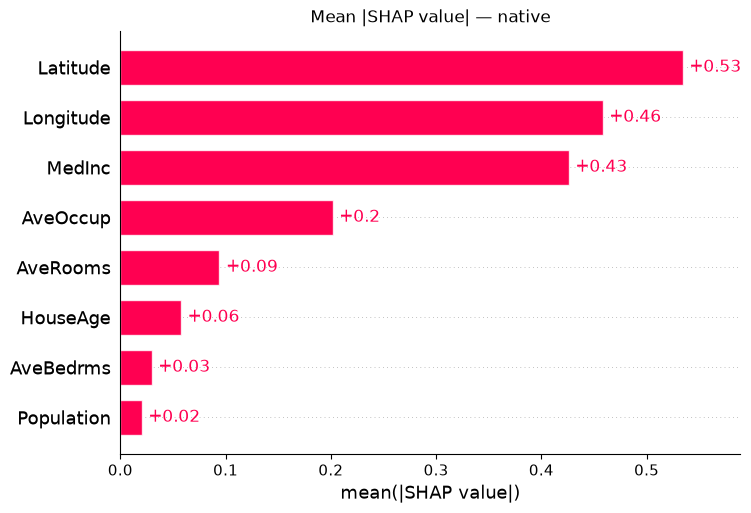

In [37]:
explainer = shap.TreeExplainer(gbm)
sv = explainer(Xte)
print(f"SHAP values: {sv.values.shape[0]:,} block groups x {sv.values.shape[1]} features")

shap.plots.bar(sv, max_display=9, show=False)
plt.title("Mean |SHAP value| \u2014 native")
plt.show()

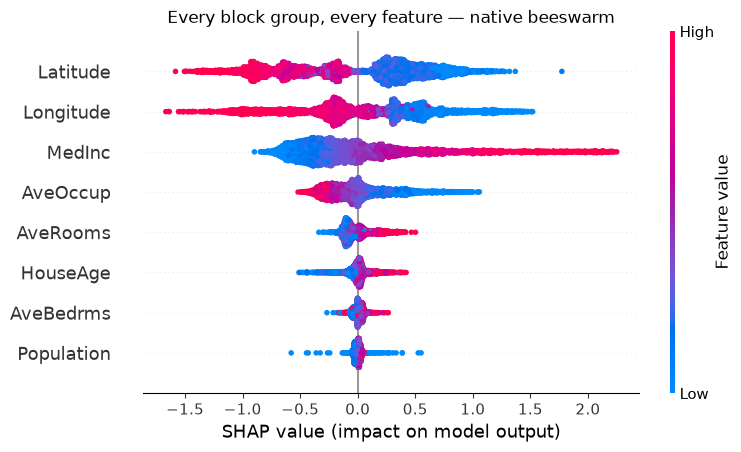

In [38]:
shap.plots.beeswarm(sv, max_display=9, show=False)
plt.title("Every block group, every feature \u2014 native beeswarm")
plt.show()

In [39]:
A.plot_global_bar(sv, Xte, title="Mean |SHAP value| \u2014 Plotly").show()
A.plot_beeswarm(sv, Xte, title="Beeswarm \u2014 Plotly (hover for values)")

**Reading the beeswarm.** Each dot is one block group. Its horizontal position is the SHAP
value — how far that feature pushed the prediction up or down — and its colour is the
feature's own value, from low to high. Features are ordered by overall importance.

* **`MedInc`** shows a clean colour gradient: high income (warm colours) sits to the right,
  pushing predictions up. Monotone, sensible, easy to explain.
* **`Latitude` and `Longitude`** have the widest spreads of all. Each has a dominant
  direction — further north and further east (warm colours) mostly pull predictions down,
  as in the linear model — but the *size* of the effect varies enormously from one block
  group to the next, because the model uses the two coordinates together. Part 9 puts them
  back on the map.
* **`AveOccup`** pushes predictions *down* when it is high — the relationship the linear
  model struggled to estimate is plainly present here.

> **This chart does not say what causes house prices.** It says which inputs *this fitted
> function* leans on. Change the model, the sample or the background, and the ranking can
> change. It is a statement about an artefact you built.

In [40]:
from scipy.stats import spearmanr

ranks = pd.DataFrame({
    "permutation: drop in R\u00b2": perm.importances_mean,
    "SHAP: mean |value| ($100k)": np.abs(sv.values).mean(axis=0)}, index=X.columns)
ranks["permutation rank"] = ranks.iloc[:, 0].rank(ascending=False).astype(int)
ranks["SHAP rank"] = ranks.iloc[:, 1].rank(ascending=False).astype(int)
rho = spearmanr(ranks.iloc[:, 0], ranks.iloc[:, 1]).statistic
print(f"Spearman correlation between the two rankings: {rho:+.2f}")
ranks.sort_values("permutation rank")

Spearman correlation between the two rankings: +1.00


,permutation: drop in R²,SHAP: mean |value| ($100k),permutation rank,SHAP rank
Latitude,1.3790,0.5343,1,1
Longitude,1.2077,0.4582,2,2
MedInc,0.4905,0.4260,3,3
AveOccup,0.1395,0.2017,4,4
AveRooms,0.0506,0.0941,5,5
HouseAge,0.0354,0.0576,6,6
AveBedrms,0.0051,0.0297,7,7
Population,0.0050,0.0203,8,8


The two methods may well agree on the *order* — compare the rank columns — but not on the
*magnitudes*, and they are not measuring the same thing:

* **Permutation importance** measures how much *accuracy* the model loses when a feature is
  scrambled — and, for correlated features, how badly it extrapolates to impossible
  combinations.
* **Mean |SHAP|** measures how much a feature *moves the predictions*, on average, whether
  or not those movements are accurate.

A feature can move predictions a great deal without helping accuracy, and vice versa. Both
are properties of the model, not of California.

---
# Part 7 — Partial dependence, one-way and two-way

**Partial dependence plots** (PDPs) show how the model's average prediction changes as one
feature — or a pair — varies. They answer questions like: *controlling for everything else,
what does latitude do to predicted prices?* They can show whether a relationship is linear,
monotone, or more complex.

Formally, for feature $j$,

$$ \widehat{\text{PD}}_j(z) \;=\; \frac{1}{n}\sum_{i=1}^{n} f\big(z,\; x^{(i)}_{-j}\big): $$

set feature $j$ to the value $z$ for *every* block group, predict, and average.

scikit-learn's `PartialDependenceDisplay` draws them for us. Below, the features are
ordered by their permutation importance, and we use a sample of 500 test block groups to
keep the computation quick. The option `method="brute"` asks scikit-learn to compute
exactly the average in the formula above; for this kind of model it would otherwise switch
to a faster shortcut that averages in a slightly different way.

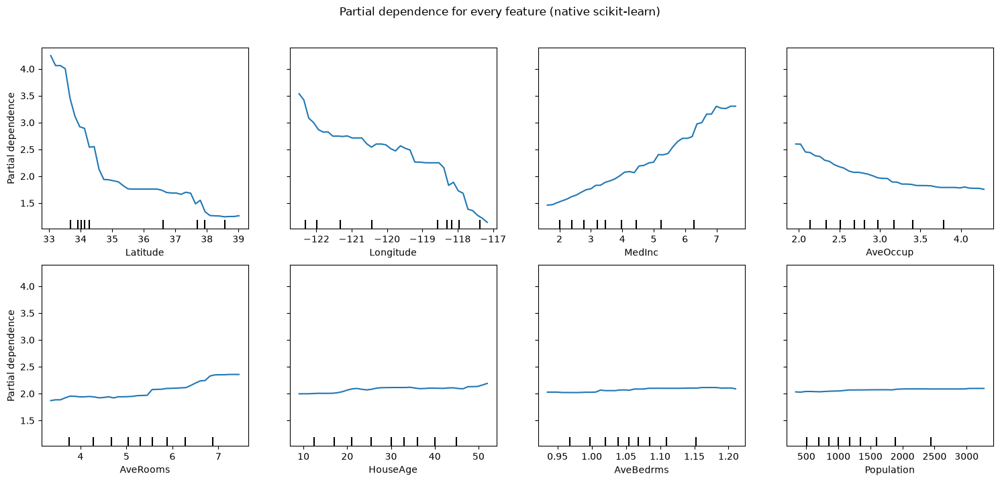

In [41]:
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

pdp_sample = Xte.sample(500, random_state=SEED)
by_importance = [X.columns[j] for j in np.argsort(-perm.importances_mean)]

fig, ax = plt.subplots(figsize=(15, 7))
PartialDependenceDisplay.from_estimator(gbm, pdp_sample, by_importance, method="brute",
                                        grid_resolution=40, n_cols=4, ax=ax)
plt.suptitle("Partial dependence for every feature (native scikit-learn)", y=1.02)
plt.tight_layout()
plt.show()

The small ticks along the bottom of each panel mark the deciles of the data: the curve is
well supported between them and extrapolating beyond.

* **`MedInc`** rises steeply and then flattens — partly real, partly the \$500,000 cap.
* **`AveOccup`** falls sharply over the first few occupants and then stays flat.
* **`Population`** is almost flat: the model barely uses it, as the permutation importance
  said.
* **`Latitude` and `Longitude`** fall from south to north and from west to east, but in
  steps and plateaux rather than straight lines: the model has learnt thresholds — where
  the metropolitan areas begin and end — not a slope.

## 7.1 Partial dependence with ICE — for the black box

Now the same native SHAP plot as in Part 4, for the boosted model: partial dependence, ICE lines,
and our San Francisco block group's SHAP value for `MedInc` as the red bar.

One technical choice to flag. For this plot we compute the SHAP value with the *same
background* the partial dependence uses, so that the two are directly comparable — using
the general exact algorithm you checked by hand in section 4.1, now applied to the full
eight-feature model. The fast `TreeExplainer` default we used in Part 6 averages in a
slightly different way; the lecture slide *SHAP, stated honestly* explains why such choices
matter, and stretch exercise 6 compares the two.

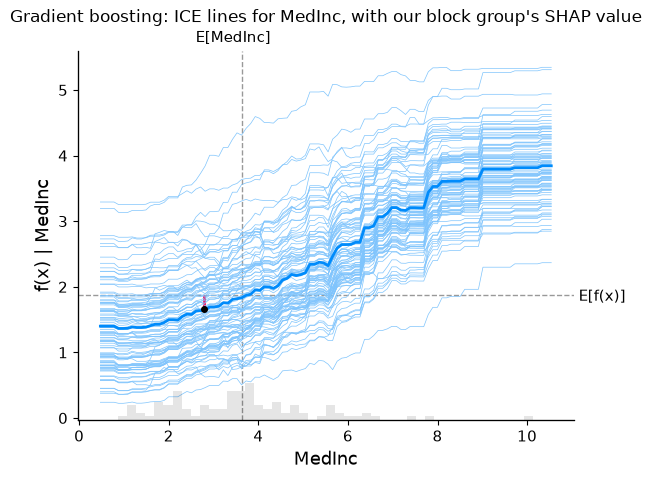

In [42]:
sv_i_int = shap.Explainer(gbm.predict, bg, algorithm="exact")(Xte.iloc[[i]])
shap.partial_dependence_plot(
    "MedInc", gbm.predict, bg,
    ice=True, model_expected_value=True, feature_expected_value=True,
    shap_values=sv_i_int, show=False)
plt.title("Gradient boosting: ICE lines for MedInc, with our block group's SHAP value")
plt.show()

In [43]:
A.plot_pdp_ice(lambda d: gbm.predict(d), bg, "MedInc", n_ice=100,
               y_label="predicted median value ($100k)",
               title="The same ICE plot in Plotly")

Compare this with the parallel lines of the linear model. The ICE lines now **fan out**:
income matters far more in some block groups than in others, which means the model has
learnt interactions — typically between income and location.

Look closely, too, at the red bar: it no longer ends exactly on the blue line. For a model
with no interactions it would. The gap — small for this block group, larger for many
others — is the part of `MedInc`'s contribution that depends on the block group's other
features. The partial dependence curve describes an average block group; ours is not
average.

> **The first lesson of this plot.** An average is not an explanation of any individual.
> Show someone the bold line and you have shown them something that may be true of nobody
> in particular — including them.

<details>
<summary><b>The mathematics, if you want it</b> — why partial dependence can mislead</summary>

Partial dependence averages over the **marginal** distribution of the other features, not
their distribution *given* feature $j$:

$$ \text{PD}_j(z) = \mathbb{E}_{X_{-j}}\big[f(z, X_{-j})\big]. $$

When $X_j$ is correlated with $X_{-j}$, this evaluates the model at combinations that
**never occur** — a block group with Atherton's income and Fresno's occupancy, or San
Francisco's latitude with Palm Springs' longitude. The model has never seen such points,
and its predictions there are extrapolation.

Two consequences recur in this lecture:

1. Evaluating models off the data manifold is precisely the weakness that Slack et al.
   (2020) exploit to fool LIME and SHAP: an adversary can detect that a query is
   unrealistic and answer it differently.
2. A steep partial dependence curve can be an artefact of extrapolation rather than
   evidence that the model relies on the feature.

Accumulated local effects (ALE) plots address this by averaging *local* changes within
narrow windows of the data, and are the better default for correlated features.
</details>

## 7.2 Two-way partial dependence: longitude × latitude

Partial dependence can also vary **two** features at once, which lets it show how they
interact. The natural pair here is the two coordinates: set *every* block group's location
to each point on a grid, predict, and average. First, the native scikit-learn display.

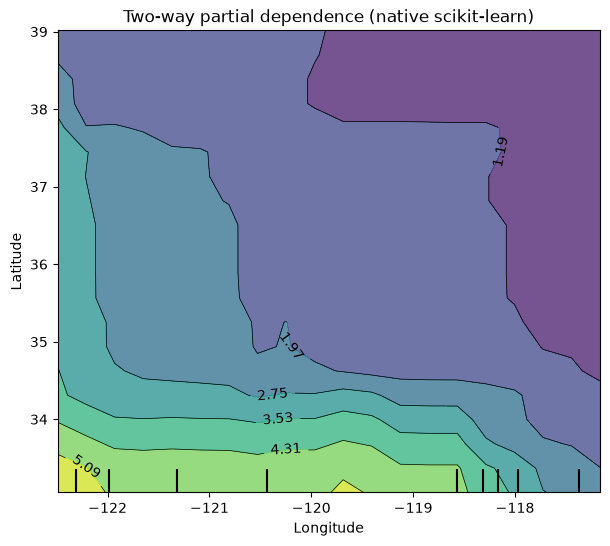

In [44]:
PartialDependenceDisplay.from_estimator(gbm, pdp_sample, [("Longitude", "Latitude")],
                                        method="brute", grid_resolution=20)
plt.gcf().set_size_inches(7, 6)
plt.title("Two-way partial dependence (native scikit-learn)")
plt.show()

### Map C — the same surface, on the map

Without a map the contour plot is hard to read. Put California's outline and cities on top,
and something important becomes visible. Each grey dot is a real block group.

In [45]:
from sklearn.neighbors import BallTree

pdr = partial_dependence(gbm, pdp_sample, ["Longitude", "Latitude"],
                         grid_resolution=30, method="brute")
pd_lons, pd_lats = pdr["grid_values"]
pd_surface = pdr["average"][0].T          # rows = latitudes, columns = longitudes

# how far is each grid point from the nearest real block group?
tree = BallTree(np.radians(X[["Latitude", "Longitude"]].values), metric="haversine")
grid = np.array([(la, lo) for la in pd_lats for lo in pd_lons])
km_to_nearest = tree.query(np.radians(grid), k=1)[0][:, 0] * 6371
print(f"share of the surface more than 25 km from any block group: "
      f"{100 * (km_to_nearest > 25).mean():.0f}%")
r_max, c_max = np.unravel_index(np.argmax(pd_surface), pd_surface.shape)
km_max = tree.query(np.radians([[pd_lats[r_max], pd_lons[c_max]]]), k=1)[0][0, 0] * 6371
print(f"highest value on the surface: {pd_surface.max():.2f} "
      f"(about ${pd_surface.max() * 100_000:,.0f}; the data stop at $500,000)")
print(f"  ...located at {pd_lats[r_max]:.2f}\u00b0N, {pd_lons[c_max]:.2f}\u00b0 \u2014 "
      f"{km_max:,.0f} km from the nearest block group")

A.california_contour(pd_lons, pd_lats, pd_surface, colorscale="Viridis",
                     colorbar_title="average prediction ($100k)", outline=outline,
                     districts=X.sample(4000, random_state=SEED),
                     title="Map C \u2014 two-way partial dependence of location")

share of the surface more than 25 km from any block group: 36%
highest value on the surface: 5.62 (about $561,884; the data stop at $500,000)
  ...located at 33.06°N, -122.49° — 253 km from the nearest block group


**Reading Map C.** The surface does pick out the expensive coast and the cheaper interior —
but look at where it *is*.

The partial dependence is defined over a rectangle, so it reports an average house price
for every point in that rectangle: the **Pacific Ocean** west of the coast, and the
**Nevada desert** to the east. A large share of the surface sits more than 25 km from any
block group — pure extrapolation, drawn with the same confidence as everywhere else.
And look at where its *highest* value lies — the printout above says. The surface's most
valuable location in California is in the open Pacific, hundreds of kilometres from any
block group, at a price above anything in the data: the model has combined "further south"
and "further west" beyond the point where either still describes land.

This is the off-manifold problem of the mathematics block above, made visible. A partial
dependence plot never tells you where it is making things up; you have to check. Map D, in
Part 9, has no such problem — it exists only where block groups do.

---
# Part 8 — Local explanation: one block group

You can always explore a single prediction in detail: the block group's characteristics,
the model's prediction for it, and *how* that prediction was built from individual
contributions. We stay with our San Francisco block group. Change `i` in section 4.1 to
follow a different one — any test-set position will do.

In [46]:
profile = pd.DataFrame({"value": Xte.iloc[i],
                        "meaning": [A.CA_LABELS[c] for c in X.columns]})
display(profile)
print(f"actual median value:          ${yte.iloc[i] * 100_000:>10,.0f}")
print(f"linear regression predicts:   ${lin.predict(Xte.iloc[[i]])[0] * 100_000:>10,.0f}")
print(f"gradient boosting predicts:   ${gbm.predict(Xte.iloc[[i]])[0] * 100_000:>10,.0f}")

,value,meaning
MedInc,2.7794,"Median income ($10,000s)"
HouseAge,52.0000,Median house age (years)
AveRooms,3.4904,Average rooms per household
AveBedrms,1.0479,Average bedrooms per household
Population,"1,266.0000",Block-group population
AveOccup,2.0224,Average occupants per household
Latitude,37.7700,Latitude (°N)
Longitude,-122.4200,Longitude (°E; negative = west)


actual median value:          $   350,000
linear regression predicts:   $   233,540
gradient boosting predicts:   $   353,201


### The waterfall plot

The waterfall explains how the SHAP values for this one block group take us from the base
value — the model's average prediction — to its specific prediction. The most influential
features are listed individually and the rest grouped together. Each feature's SHAP value
is added (red) or subtracted (blue) in turn. It is the most useful single tool for local
interpretation: it shows precisely how each feature affected *this* prediction.

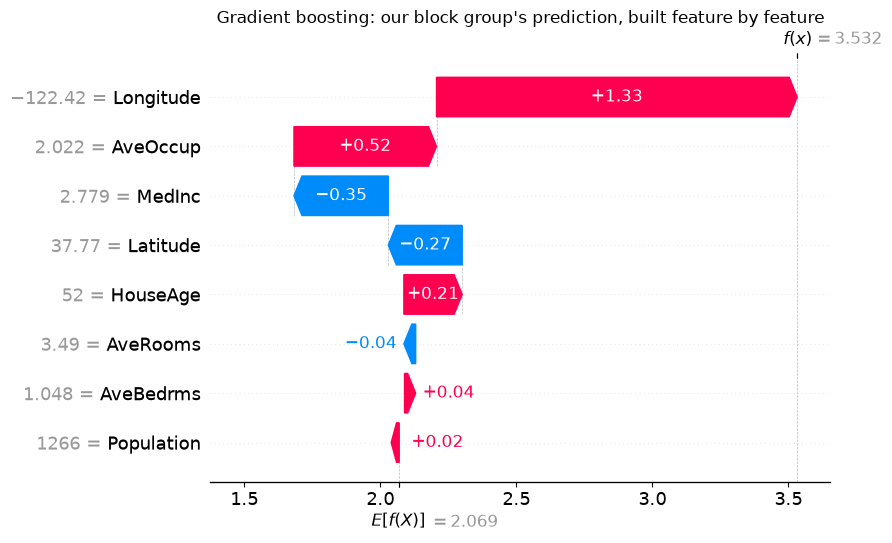

In [47]:
shap.plots.waterfall(sv[i], max_display=10, show=False)
plt.title("Gradient boosting: our block group's prediction, built feature by feature")
plt.show()

In [48]:
A.plot_waterfall(sv.values[i], sv.base_values[i], X.columns, Xte.iloc[i].values,
                 value_label="predicted median value ($100k)",
                 title="The same waterfall in Plotly")

### The force plot

The force plot shows the same numbers as a tug of war. Features in **red** push the
prediction higher; features in **blue** push it lower. The width of each segment is the
size of its SHAP value — note that the numbers printed beside the feature names are the
feature *values* (for example the block group's median income), not their SHAP values.
The prediction sits where the two sides balance, and the grey *base value* marks where it
would sit with no information about this block group at all.

The interactive version needs JavaScript: it renders in Jupyter and in VS Code (you may need
to *trust* the notebook), but not on GitHub. The static version below it works everywhere.

In [49]:
shap.initjs()
shap.force_plot(sv.base_values[i], sv.values[i], Xte.iloc[i].round(2))

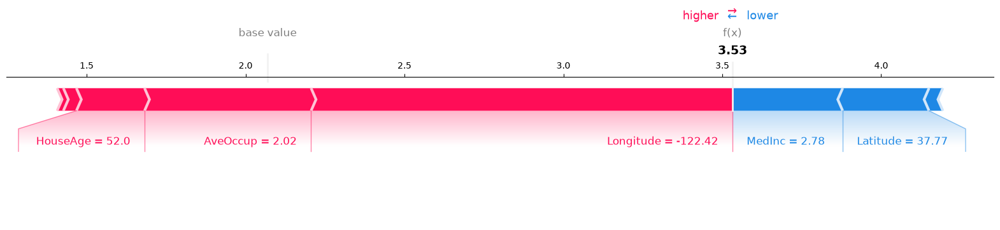

In [50]:
shap.force_plot(sv.base_values[i], sv.values[i], Xte.iloc[i].round(2),
                matplotlib=True, show=False)
plt.show()

### The decision plot

A decision plot shows many predictions at once. Each line is one block group: it starts at
the base value at the bottom and moves left or right as each feature's SHAP value is added,
features ordered from least to most important going up, ending at that block group's
prediction at the top. Lines that fan out late are distinguished by the most important
features. Our San Francisco block group is highlighted among 40 others drawn at random.

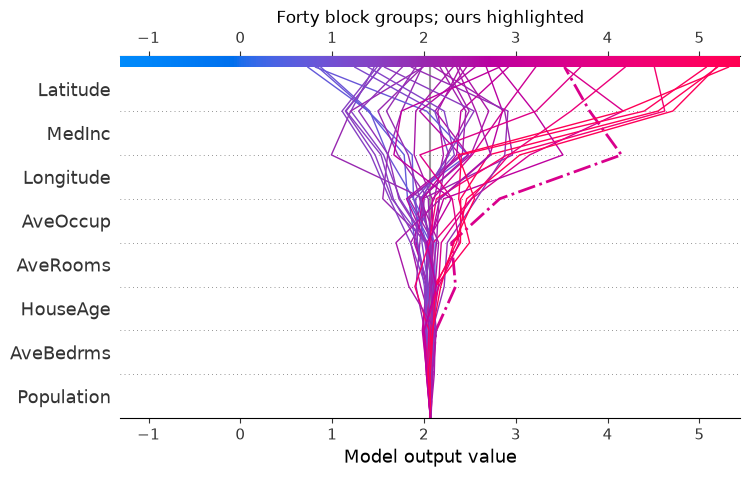

In [51]:
rng = np.random.RandomState(SEED)
others = rng.choice([k for k in range(len(Xte)) if k != i], 39, replace=False)
rows_dp = np.r_[i, others]
shap.decision_plot(float(sv.base_values[i]), sv.values[rows_dp], Xte.iloc[rows_dp],
                   highlight=[0], show=False)
plt.title("Forty block groups; ours highlighted")
plt.show()

### Check the arithmetic

Never take an attribution plot on trust. Two properties can be verified directly.

* The **base value** is what we predict with no information about a particular block group.
  For `TreeExplainer`'s default it is the average of the model's predictions over the
  training data.
* **Efficiency**: the base value plus the sum of the SHAP values is exactly the prediction.

In [52]:
base = float(sv.base_values[i])
print(f"base value:                           {base:.6f}")
print(f"average prediction on training data:  {gbm.predict(Xtr).mean():.6f}\n")

phi_sum = sv.values[i].sum()
print(f"base value + sum of SHAP values:      {base + phi_sum:.6f}")
print(f"the model's prediction:               {gbm.predict(Xte.iloc[[i]])[0]:.6f}")
print(f"(sum of SHAP values alone:            {phi_sum:+.6f} \u2014 the distance from base to prediction)")

base value:                           2.069087
average prediction on training data:  2.069087

base value + sum of SHAP values:      3.532013
the model's prediction:               3.532013
(sum of SHAP values alone:            +1.462926 — the distance from base to prediction)


### Same block group, two models

The feature values are identical — it is the same block group, after all — but the two
models make different predictions and explain them differently.

* **Linear regression** assumes each feature has a fixed effect everywhere. Its SHAP values
  are just coefficient × distance from the average, so a feature always pushes in the same
  direction for block groups on the same side of its average.
* **Gradient boosting** lets each feature's contribution depend on its own value *and* on the other
  features. Its SHAP values reflect that.

In [53]:
both = pd.DataFrame({"feature value": Xte.iloc[i],
                     "linear SHAP": sv_lin.values[i],
                     "boosted SHAP": sv.values[i]})
both.loc["base value"] = [np.nan, sv_lin.base_values[i], sv.base_values[i]]
both.loc["prediction"] = [np.nan, lin.predict(Xte.iloc[[i]])[0],
                          gbm.predict(Xte.iloc[[i]])[0]]
display(both)

fig = go.Figure()
for col, colour in [("linear SHAP", A.GREY), ("boosted SHAP", A.NAVY)]:
    fig.add_trace(go.Bar(y=list(X.columns), x=both.loc[list(X.columns), col],
                         orientation="h", name=col, marker_color=colour))
fig.add_vline(x=0, line=dict(color="#999999", width=1))
A.layout(fig, "One block group, two models: contributions compared ($100k)", height=460,
         barmode="group", xaxis_title="SHAP value")

,feature value,linear SHAP,boosted SHAP
MedInc,2.7794,-0.3680,-0.3468
HouseAge,52.0000,0.2367,0.2144
AveRooms,3.4904,0.2227,-0.0435
AveBedrms,1.0479,-0.0751,0.0410
Population,"1,266.0000",0.0000,0.0196
AveOccup,2.0224,0.0033,0.5240
Latitude,37.7700,-0.9879,-0.2716
Longitude,-122.4200,1.3281,1.3258
base value,NaN,1.9755,2.0691
prediction,NaN,2.3354,3.5320


Two rows deserve a closer look.

* **Occupancy.** The linear model gives `AveOccup` almost nothing — for *every* block group,
  not just this one, because its occupancy coefficient was owned by a handful of extreme
  rows (section 3.2). The boosted model, which splits the data into ranges instead of fitting one
  slope through all of it, can give occupancy a substantial contribution.
* **Location.** The linear model's latitude and longitude contributions are large and pull
  in opposite directions, partly cancelling — two slopes on raw coordinates, each measured
  from the average location. The boosted model's are shaped by what it has learnt about *this part of
  California*.

Same data, same block group, two quite different accounts of why it costs what it does.

### ★ Deep dive — the heatmap plot

The heatmap shows SHAP values for many block groups at once: one column per block group,
one row per feature, colour for the SHAP value. Block groups are clustered by the
similarity of their explanations, and the line across the top shows each prediction. It is
a quick way to see *groups* of block groups that the model treats alike.

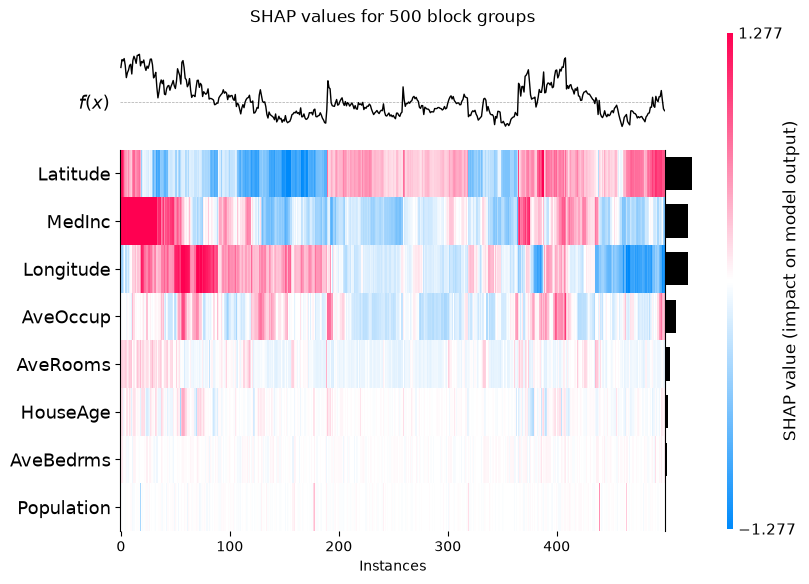

In [54]:
shap.plots.heatmap(sv[:500], max_display=9, show=False)
plt.title("SHAP values for 500 block groups")
plt.show()

---
# Part 9 — Geography through SHAP: the turn

`Latitude` and `Longitude` sat at the top of both global rankings in Part 6. A model is
using *where a block group is* to predict what its houses cost. Start with latitude on its
own: its SHAP value against its value, coloured by longitude.

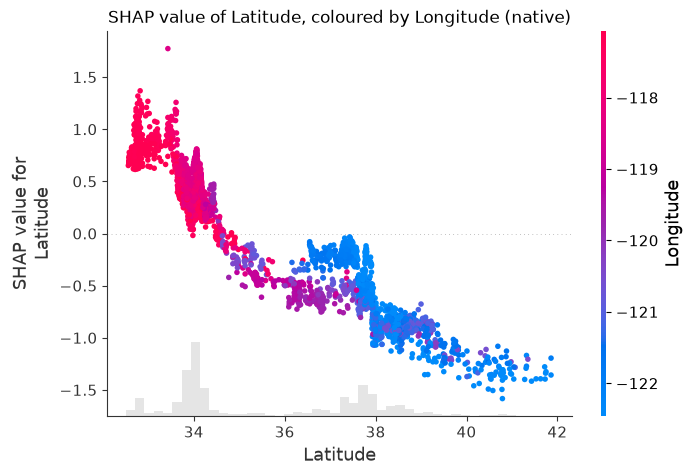

In [55]:
shap.plots.scatter(sv[:, "Latitude"], color=sv[:, "Longitude"], show=False)
plt.title("SHAP value of Latitude, coloured by Longitude (native)")
plt.show()

In [56]:
A.plot_dependence(sv, Xte, "Latitude", colour_by="Longitude",
                  title="SHAP value of Latitude \u2014 a map, drawn sideways")

Latitude's contribution falls from south to north — the Los Angeles basin, around 34°N,
sits highest — but not smoothly. Find the Bay Area's latitude, around 37.5°N: the points
split into two bands. Block groups further **west** (blue: the Bay Area itself) sit well
above those further **east** (purple: the Central Valley) at *exactly the same latitude*.

That split is an interaction made visible: the model's verdict on latitude depends on
longitude. It has no concept of a city — only that certain *combinations* of coordinates
predict certain prices.

A sideways view is still hard to read. Put the attributions back on the map.

### Map D — what the black box attributes to location

For each test block group, add its SHAP values for latitude and longitude. By additivity,
that sum is the total credit the model gives to **where the block group is**, holding its
other features at their own values. Red means location pushed the prediction up; blue,
down.

In [57]:
location_effect = sv[:, "Latitude"].values + sv[:, "Longitude"].values
mapD = Xte.assign(location_effect=location_effect)

A.california_map(mapD, color="location_effect", colorscale="RdBu_r", cmid=0,
                 outline=outline, marker_size=4.5,
                 color_label="location effect ($100k)",
                 title="Map D \u2014 SHAP: what the boosted model attributes to location")

In [58]:
top = mapD.nlargest(200, "location_effect")
bottom = mapD.nsmallest(200, "location_effect")
bay = (top.Latitude.between(37.2, 38.1) & top.Longitude.between(-122.6, -121.7)).mean()
socal = (top.Latitude.between(32.6, 34.5) & top.Longitude.between(-119.3, -117.0)).mean()
city, km = A.nearest_city(bottom.Latitude.median(), bottom.Longitude.median())

print(f"of the 200 largest location premiums: {100 * bay:.0f}% in the Bay Area, "
      f"{100 * socal:.0f}% in coastal Southern California")
print(f"the 200 largest location discounts centre on {city} "
      f"({km:.0f} km from their median location)")
spread = location_effect.max() - location_effect.min()
print(f"location alone moves predictions from {location_effect.min() * 100_000:+,.0f} $ "
      f"to {location_effect.max() * 100_000:+,.0f} $ \u2014 a swing of about "
      f"${spread * 100_000:,.0f}")

of the 200 largest location premiums: 42% in the Bay Area, 55% in coastal Southern California
the 200 largest location discounts centre on Fresno (21 km from their median location)
location alone moves predictions from -139,655 $ to +252,033 $ — a swing of about $391,688


**Map B beside Map D.** The linear model could only draw a tilted plane: *nearer the coast
is dearer*. The black box has drawn the **metropolitan areas** — the Bay Area and coastal
Southern California lit up in red, the Central Valley around Fresno in deep blue — with
location alone worth several hundred thousand dollars from one end of the state to the
other.

That is a better model of California. It is also a model that has learnt the *history* of
California's places, and that is where this lecture's concern begins.

### ★ Deep dive — the four maps side by side

In [59]:
from plotly.subplots import make_subplots

poster = make_subplots(rows=2, cols=2, horizontal_spacing=0.07, vertical_spacing=0.09,
                       subplot_titles=["A \u2014 the data", "B \u2014 the linear plane",
                                       "C \u2014 partial dependence", "D \u2014 SHAP"])
poster.add_trace(go.Scattergl(x=df.Longitude, y=df.Latitude, mode="markers",
                              hoverinfo="skip", showlegend=False,
                              marker=dict(size=2.5, color=df.MedHouseVal,
                                          colorscale="Viridis", opacity=0.7)), row=1, col=1)
poster.add_trace(go.Contour(x=lons, y=lats, z=plane, colorscale="RdBu_r", zmid=0,
                            showscale=False, opacity=0.85, line=dict(width=0.4),
                            contours=dict(coloring="fill")), row=1, col=2)
poster.add_trace(go.Contour(x=pd_lons, y=pd_lats, z=pd_surface, colorscale="Viridis",
                            showscale=False, opacity=0.85, line=dict(width=0.4),
                            contours=dict(coloring="fill")), row=2, col=1)
poster.add_trace(go.Scattergl(x=Xte.Longitude, y=Xte.Latitude, mode="markers",
                              hoverinfo="skip", showlegend=False,
                              marker=dict(size=3, color=location_effect, cmid=0,
                                          colorscale="RdBu_r", opacity=0.8)), row=2, col=2)
for r in (1, 2):
    for c in (1, 2):
        A.add_california_context(poster, outline, cities=False, row=r, col=c)
        A.california_axes(poster, row=r, col=c)
A.layout(poster, "Four answers to one question: what is location worth?", height=1000)

### How much of the model is location?

Refit the boosted model three ways — with all eight features, with the six that are *not*
coordinates, and with the two coordinates alone — and compare them on the test set.

In [60]:
geo = ["Latitude", "Longitude"]
non_geo = [c for c in X.columns if c not in geo]
fits = {"all eight features": list(X.columns),
        "the six non-geographic features": non_geo,
        "latitude and longitude only": geo}
rows = []
for name, cols in fits.items():
    m = HistGradientBoostingRegressor(max_iter=500, max_depth=4, learning_rate=0.05,
                                      early_stopping=False,
                                      random_state=SEED).fit(Xtr[cols], ytr)
    rows.append({"features": name, "number": len(cols),
                 "test R\u00b2": r2_score(yte, m.predict(Xte[cols]))})
pd.DataFrame(rows).set_index("features")

,number,test R²
features,,
all eight features,8,0.8402
the six non-geographic features,6,0.7137
latitude and longitude only,2,0.6966


**Two coordinates do about as well as the other six features combined.** Latitude and
longitude are not a minor geographic control: they carry roughly as much predictive
information as income, housing stock and occupancy together.

### The turn

For house prices, that is unremarkable. Location genuinely carries information about
climate, coastline, employment and schools.

But ask the question this lecture exists to ask: **what else does a coordinate encode?**
A coordinate is a compressed summary of everything true about a place — including its
history. In American housing, that history includes *redlining*: the federal grading of
neighbourhoods by their racial composition from the 1930s, which shaped lending and property
values for decades, and whose boundaries can still be seen in prices today.

The model was never given race. It was given a coordinate. In housing and credit data, **a
coordinate is not a neutral feature** — it is what the lecture calls a *proxy*: individually
innocuous, and carrying the information anyway.

In `Lec09a` we meet the same structure where it is not academic: a lending decision, a
protected attribute that we delete from the data, and the question of whether deleting it
achieves anything.

---
# Part 10 — Counterfactuals: what would have to change?

Every method so far has looked *backwards* at a prediction and asked where it came from. A
**counterfactual explanation** looks *forwards*: what is the smallest change to the inputs
that would give a different prediction? It is the form of explanation an affected person
actually wants — "what would it take?" — and the lecture's credit example turns on it.

We use **DiCE** (Diverse Counterfactual Explanations; Mothilal, Sharma and Tan, 2020). For a
regression model we ask for counterfactuals whose prediction falls in a *desired range*:
here, **\$50,000 to \$100,000 higher** than the model currently predicts. We take a
block group of modest predicted value — the first one ranked between the 30th and 40th
percentiles of test-set predictions.

Two helper functions keep the cells short. `counterfactuals()` runs the search and returns
`None` if DiCE finds nothing. `what_changed()` shows only the features a counterfactual
altered, with the original row at the bottom, plus a column of the model's own prediction
for each row. We compute that column ourselves rather than read DiCE's: for regression
models DiCE rounds the outcome it reports, which would hide whether each counterfactual
actually reached the target. Check the arithmetic, as in Part 8.

In [61]:
import contextlib, io
import dice_ml

dice_data = dice_ml.Data(dataframe=Xtr.assign(MedHouseVal=ytr),
                         continuous_features=list(X.columns), outcome_name="MedHouseVal")
dice_model = dice_ml.Model(model=gbm, backend="sklearn", model_type="regressor")
dice = dice_ml.Dice(dice_data, dice_model, method="random")

pred_te = gbm.predict(Xte)
modest = np.argsort(pred_te)[int(0.30 * len(Xte)):int(0.40 * len(Xte))]
j = int(modest[0])
city_j, km_j = A.nearest_city(Xte.iloc[j].Latitude, Xte.iloc[j].Longitude)
print(f"block group at test position {j}, near {city_j} ({km_j:.0f} km): "
      f"predicted ${pred_te[j] * 100_000:,.0f}")


def counterfactuals(pos, features, n=4, permitted=None):
    # Returns a DataFrame of counterfactuals, or None if DiCE finds none.
    # DiCE prints to the screen when it fails; we silence that and use the result.
    extra = {"permitted_range": permitted} if permitted else {}
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            cf = dice.generate_counterfactuals(
                Xte.iloc[[pos]], total_CFs=n, features_to_vary=features,
                desired_range=[pred_te[pos] + 0.5, pred_te[pos] + 1.0],
                random_seed=SEED, **extra)
        return cf.cf_examples_list[0].final_cfs_df
    except Exception:
        return None


def what_changed(pos, cfs):
    original = Xte.iloc[pos]
    moved = [c for c in X.columns
             if not np.allclose(cfs[c].astype(float), original[c], atol=1e-6)]
    table = cfs[moved].astype(float).copy()
    table["model predicts ($100k)"] = gbm.predict(cfs[list(X.columns)].astype(float))
    table.loc["original"] = list(original[moved]) + [pred_te[pos]]
    return table.round(3)

block group at test position 861, near San Diego (11 km): predicted $140,089


### (a) Allowed to change anything

In [62]:
cf_all = counterfactuals(j, "all")
what_changed(j, cf_all) if cf_all is not None else print("no counterfactual found")

100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


,HouseAge,AveRooms,model predicts ($100k)
0,31.6000,85.4000,2.0010
1,43.0000,86.0000,1.9700
2,43.0000,13.8000,1.9160
3,43.0000,118.4000,1.9700
original,43.0000,5.1130,1.4010


DiCE has found ways to raise the predicted value — look at *what* it changed. Typically it
is some mix of median income, population and rooms per household, often set to values no
real neighbourhood has — and sometimes it simply moves the block group, changing its
latitude or longitude (the tally below counts how often).

Every one of these is a valid counterfactual for the *model*: change the inputs this way
and its prediction moves into the target range. Almost none is useful advice. "Move the
neighbourhood" and "make the residents richer" are not things a homeowner can do.
Counterfactual search finds the nearest point across a boundary in *feature space*, and
feature space does not know which features can change.

### (b) Only what a homeowner could change

Restrict the search to renovation: rooms and bedrooms.

In [63]:
cf_reno = counterfactuals(j, ["AveRooms", "AveBedrms"])
what_changed(j, cf_reno) if cf_reno is not None else print("no counterfactual found")

100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


,AveRooms,model predicts ($100k)
0,38.4000,1.9700
1,26.7000,1.9700
2,59.4000,1.9700
3,140.7000,1.9700
original,5.1130,1.4010


Actionable — and, look at the room counts, absurd. With only two features to change, DiCE
reaches the target range by pushing rooms per household towards the extreme values of
section 1.2: territory where the model has seen only a handful of odd block groups and
behaves accordingly.

**Actionability is not enough; a counterfactual must also be plausible.** Limit the
renovation to something a household could do: up to two more rooms, one of which may be a
bedroom.

### (c) Only what a homeowner could plausibly change

In [64]:
r0, b0 = float(Xte.iloc[j].AveRooms), float(Xte.iloc[j].AveBedrms)
plausible = {"AveRooms": [r0, r0 + 2.0], "AveBedrms": [b0, b0 + 1.0]}
cf_plaus = counterfactuals(j, ["AveRooms", "AveBedrms"], permitted=plausible)
(what_changed(j, cf_plaus) if cf_plaus is not None
 else print("No counterfactual exists within these bounds: nothing a household could "
            "plausibly do raises this prediction by $50,000."))

100%|██████████| 1/1 [00:00<00:00,  5.55it/s]


No counterfactual exists within these bounds: nothing a household could plausibly do raises this prediction by $50,000.


How typical is that? Repeat all three searches for 25 block groups of modest predicted
value. The cell takes a few seconds.

In [65]:
tally = {"(a) change anything": 0, "(b) renovation only": 0,
         "(c) plausible renovation": 0}
rooms_absurd = location_moved = n_cf = 0
for pos in modest[:25]:
    pos = int(pos)
    got = counterfactuals(pos, "all", n=3)
    if got is not None:
        tally["(a) change anything"] += 1
        for k in range(len(got)):
            n_cf += 1
            rooms_absurd += float(got.iloc[k]["AveRooms"]) > 15
            location_moved += any(not np.isclose(float(got.iloc[k][g]), Xte.iloc[pos][g])
                                  for g in ("Latitude", "Longitude"))
    tally["(b) renovation only"] += counterfactuals(pos, ["AveRooms", "AveBedrms"], n=1) is not None
    r0, b0 = float(Xte.iloc[pos].AveRooms), float(Xte.iloc[pos].AveBedrms)
    tally["(c) plausible renovation"] += counterfactuals(
        pos, ["AveRooms", "AveBedrms"], n=1,
        permitted={"AveRooms": [r0, r0 + 2.0], "AveBedrms": [b0, b0 + 1.0]}) is not None

print("block groups (of 25) with at least one counterfactual:")
for k, v in tally.items():
    print(f"  {k:28s} {v:2d}")
print(f"\namong the {n_cf} unconstrained counterfactuals: {rooms_absurd} set rooms per "
      f"household above 15, and {location_moved} moved the block group")

100%|██████████| 1/1 [00:00<00:00,  6.13it/s]


block groups (of 25) with at least one counterfactual:
  (a) change anything          25
  (b) renovation only          22
  (c) plausible renovation      4

among the 75 unconstrained counterfactuals: 49 set rooms per household above 15, and 17 moved the block group


Three answers to "what would it take?", depending on the constraints:

* **Unconstrained**, a counterfactual nearly always exists — because the search is free to
  move the neighbourhood or invent impossible houses.
* **Actionable only**, one still usually exists — through implausible values.
* **Actionable and plausible**, one rarely exists at all.

The honest answer for most of these block groups is: *nothing a household can reasonably do
raises the model's valuation by \$50,000.* That is a legitimate, useful finding — and one
that no attribution plot would have told you.

In `Lec09a` the same question is asked about a person whose mortgage application was
declined, and the answer — for many applicants — is the same.

---
# Part 11 — Wrap-up

### Which method answers which question

| The question | The method | Where |
|---|---|---|
| What is the model's mechanism? | Interpretable by design: read the coefficients | Part 3 |
| Which features does the model use overall? | Permutation importance; mean \|SHAP\| | Part 6 |
| How does the average prediction move with a feature, or a pair? | Partial dependence, one-way and two-way | Part 7 |
| Does that average hold for each case? | ICE lines | Parts 4 and 7 |
| Why did *this* case get *this* prediction? | Local SHAP: waterfall, force, decision plots | Part 8 |
| What would have to change for a different outcome? | Counterfactuals (DiCE) | Part 10 |

Each method answers its own question and none of the others. Most confusion about
explainable AI — in practice and in regulation — comes from asking one of them another's
question. This table is the lecture slide *Four questions, four families of method*, filled
in with the plots you have now read.

### Exercises

#### Core

1. **A coefficient in a sentence.** Choose two coefficients from Part 3. For each, write one
   sentence that includes the feature's units, the target's units, the *holding everything
   else constant* clause, and whether it is statistically distinguishable from zero.

2. **Another block group.** In section 4.1, replace San Francisco with another city from
   `A.CA_CITIES` and re-run Parts 4 and 8. Which features drive that block group's
   prediction, and how does its location effect compare?

3. **Check the arithmetic.** For three different block groups, verify that the base value
   plus the sum of SHAP values equals the prediction, for both models.

4. **A proxy hunt.** Train a model to predict `Latitude` from the six non-geographic
   features. How well can you recover it? What does your answer imply about deleting a
   feature you consider sensitive?

5. **Read Map C.** Hover over a point in the Pacific Ocean and report the partial dependence
   there. What would you say to someone who quoted that number as "the value of a location
   near the coast"?

#### Stretch

6. **Two SHAP conventions.** Compute our San Francisco block group's SHAP values with
   `shap.Explainer(gbm.predict, bg, algorithm="exact")` — every missing feature
   filled in from the 100-row background — and compare them with the default
   `TreeExplainer(gbm)` values from Part 6, which average along the paths of each
   tree instead. Which features move most? Which would you defend to a regulator, and why?

7. **Another interaction.** Draw a two-way partial dependence plot for `MedInc` × `HouseAge`.
   Is there an interaction? Compare the ICE lines for `MedInc` in young and old
   neighbourhoods.

8. **Robust recourse.** In Part 10, widen the plausible renovation step by step — more
   rooms, more bedrooms — until counterfactuals exist for at least half of the 25 block
   groups. How large must the renovation be? Would you put that in a letter to a homeowner?

9. **The cap.** Refit the boosted model without the block groups at the \$500,000 cap and redraw
   Map D. Which conclusions from Part 9 survive?

10. **A noise feature.** Add a column of pure random noise to the features, refit, and
    compute its permutation importance and mean |SHAP|. Neither will be exactly zero.
    What threshold would you require before calling a feature a "driver" in a model
    document?

### What to carry into `Lec09a`

* **Know the data before you explain the model.** Top-codes, extreme ratios and
  aggregation all shaped what these models could learn — and no explanation surfaced them.
* **An interpretable model still has to be interpreted**, and its coefficients can be
  owned by a handful of rows.
* **SHAP generalises "coefficient × deviation from average"**; it is exact arithmetic
  about *your fitted function*, not a statement about the world.
* **An average is not an explanation of anyone**, and partial dependence will happily
  describe the Pacific Ocean.
* **Deleting a sensitive feature does not delete the information.** Location carried as
  much as six other features combined.
* **A counterfactual needs actionability *and* plausibility** — and once it has both, the
  honest answer is often "nothing you can do".